# 0509 — XGBoost Cognitive Cascade (Post-Ablation)

This is the decision system Project Pienza exists to produce: a two-stage cascade that filters and classifies why a ride offer would be rejected, then backtests those decisions against real earnings. Layer 1 is a triage classifier that filters out non-operational noise; Layer 2 resolves the nuanced remainder (Accepted vs. Expected Value Gamble vs. Strategic Mismatch), with a lightweight 6-feature variant for comparison. 

```mermaid
flowchart TD
    subgraph P1["Phase 1 - Data Foundry"]
        p1a["Ingest v_ML_Supervised,\npurge rare class"] --> p1b["Zone grouping +\nmerged zone names"]
        p1b --> p1c["Wide (41-feat) and\nFocused (20-feat) universes"]
        p1c --> p1d["Geo + temporal\nfeature-selection arenas"]
        p1d --> p1e["Scale, one-hot fuse,\nwalk-forward folds"]
    end

    subgraph P2["Phase 2 - Layer 1 (Triage)"]
        p2a["Target: 4 reject reasons\n+ THE_NUANCED_REST"] --> p2b["Tune + fit\nXGBClassifier"]
        p2b --> p2c["Threshold rescue,\nSHAP, ROC/PR-AUC"]
    end

    subgraph P3["Phase 3 - Layer 2 (Nuance)"]
        p3a["Isolate Nuanced universe,\nLayer 2 target"] --> p3b["Tune + fit\nchampion + lightweight variant"]
        p3b --> p3c["Week 6 holdout eval,\nROC/PR-AUC, learning curve"]
        p3c --> p3d["3.11 Full strategic\nDNA atlas (SHAP)"]
    end

    P1 --> P2 --> P3

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```

## Phase 1 — Data Foundry

Builds the raw feature universes (Wide and Focused), engineers the zone/time/context features, runs feature-selection audits to pick the winning signals, and sets up the walk-forward temporal folds used by every downstream layer.

#### 1.1 — Setup, connectivity, and visual identity

Silences warnings, connects to the local SQLite database, and applies the shared visual theme.

In [70]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None

import os
import re
import re as _re
import json
import json as _json
import time
import builtins
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import shap
import xgboost as xgb
from xgboost import XGBClassifier
from sqlalchemy import create_engine
import sqlite3
import joblib
from scipy.stats import uniform, randint
from IPython.display import display, Markdown

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.model_selection import (
    cross_validate, StratifiedKFold, RandomizedSearchCV,
    validation_curve, learning_curve,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

PROJECT_ROOT = "/workspaces/pienza"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
DUMP_DIR = os.path.join(DATA_DIR, "dumped_files")
DB_PATH = os.path.join(DATA_DIR, "pienza.db")

os.makedirs(DUMP_DIR, exist_ok=True)

FORCE_UPDATE = False
DATE_PREFIX = "260505"
NOTEBOOK_ID = "0509X"

if not os.path.exists(DB_PATH):
    print(f"CRITICAL: Database not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"SQL Engine Active: {DB_PATH}")

PIENZA_PURPLE = '#440154'
PIENZA_TEAL = '#21918c'
PIENZA_GREY = '#FAFAFA'
PIENZA_TEXT = '#121212'
cmap_pienza = mcolors.LinearSegmentedColormap.from_list("pienza_teal", ["#FFFFFF", PIENZA_TEAL])

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_GREY,
    'axes.facecolor': PIENZA_GREY,
    'text.color': PIENZA_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': PIENZA_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("Visual Identity Loaded: Pienza (Light Mode).")
print(f"SOP Cero-Esperas cargado (Notebook {NOTEBOOK_ID}).")
print("\n--- SYSTEM READY ---")


SQL Engine Active: /workspaces/pienza/data/pienza.db
Visual Identity Loaded: Pienza (Light Mode).
SOP Cero-Esperas cargado (Notebook 0509X).

--- SYSTEM READY ---


#### 1.2 — Raw feature universes (no PCA)

Ingests v_ML_Supervised and builds the Wide (41-feature) and Focused (20-feature) numeric universes, with log transforms and scaling.

In [71]:
print("Ingesting v_ML_Supervised and forging RAW analytical universes...")

query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
rows_before = len(df_input)
# Filter out class 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# UNIVERSE A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSE B: The Focused Set (20 Features)
focused_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, focused_list)

def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

print("Scaling Universes (StandardScaler only)...")

scaler_a = StandardScaler()
X_league_a = pd.DataFrame(
    scaler_a.fit_transform(X_a_log),
    index=X_a_log.index,
    columns=X_a_log.columns
)


Ingesting v_ML_Supervised and forging RAW analytical universes...
Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
Scaling Universes (StandardScaler only)...


#### 1.3 — Class mapping audit

Reveals exactly how LabelEncoder mapped the raw reason IDs to model classes.

In [72]:
print("AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# LabelEncoder stores its classes in le.classes_
# The array index is the model class; the value is the original ID (y_raw)
model_classes = le.classes_

meaning_map = {
    9999: "ACCEPTED (Was Null)",
    1: "dropoff_non_operational",
    2: "dropoff_proxy",
    3: "low_profitability",
    4: "long_pickup_time",
    5: "dropoff_strategic_mismatch",
    6: "expected_value_gamble",
    7: "system_logic_failure"
}

audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    count = np.sum(y == model_class_id)

    meaning = meaning_map.get(original_raw_id, "UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("WARNING: Class 0 is 'dropoff_non_operational' (ID 1).")
    print("The model will treat rejection ID 1 as its base class (0).")
    print("Accepted (9999) ended up last.")
else:
    print("Class 0 appears to be Accepted. (Check the table above)")

AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,dropoff_non_operational,2366
1,1,2,dropoff_proxy,239
2,2,3,low_profitability,838
3,3,4,long_pickup_time,366
4,4,5,dropoff_strategic_mismatch,275
5,5,6,expected_value_gamble,330
6,6,9999,ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
The model will treat rejection ID 1 as its base class (0).
Accepted (9999) ended up last.


#### 1.4 — Zone grouping and merged names

Groups redundant dropoff polygons under a canonical ID and builds a merged, human-readable zone name.

In [73]:
print("Mapping IDs and building merged zone names...")

id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# Group by the new ID and join the original names with a double underscore separator
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'),  # already the fused name, so first() is representative
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

Mapping IDs and building merged zone names...
Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


#### 1.5 — Master zone coalesce

Combines the human-grouped polygons with the machine (HDBSCAN) clusters into a single final_zone_id/name, with a trajectory audit.

In [74]:
print("Executing Master Coalesce with Real HDBSCAN Names...")


# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'], # Human merged zone name
    df_input['dropoff_hdbscan_name'] # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")


# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

Executing Master Coalesce with Real HDBSCAN Names...
Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


#### 1.6 — Zone ID-to-name lookup

Builds a dictionary mapping each final_zone_id to its human-readable name.

In [75]:
# .drop_duplicates() is essential so the dict build doesn't fail
zone_map = df_input[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

print(f"Mapping Dictionary Created. Size: {len(zone_map)} zones.")
print(f"Test P_25: {zone_map.get('P_25', 'Not Found')}")
print(f"Test C_1: {zone_map.get('C_1', 'Not Found')}")

Mapping Dictionary Created. Size: 67 zones.
Test P_25: roma_condesa_2
Test C_1: terminal_1_aicm


#### 1.7 — Geospatial feature-selection arena

Compares H3, polygon, HDBSCAN, and final_zone_id on mutual information and chi-squared to pick the winning geospatial feature.

Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


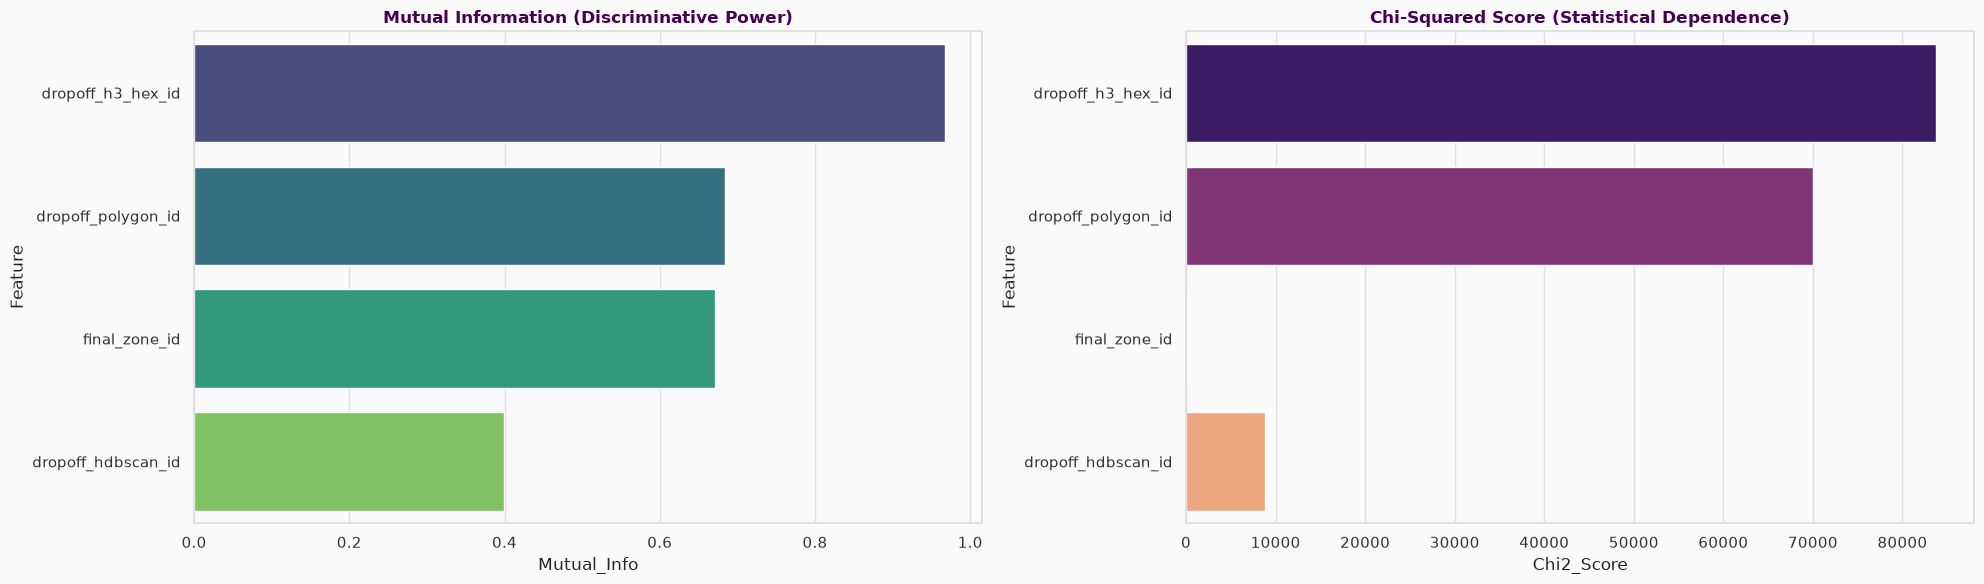

EXACT VALUES FOR THE GEO ARENA:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770


In [76]:
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # built in the previous cell
]

geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# Local encoding, to avoid depending on other cells' state
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# y is the multiclass target defined in Cell 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Mutual Information (Discriminative Power)", fontweight='bold', color=PIENZA_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Statistical Dependence)", fontweight='bold', color=PIENZA_PURPLE)

plt.tight_layout()
plt.show()

print("EXACT VALUES FOR THE GEO ARENA:")
display(geo_report)

<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

*Verdict: `final_zone_id` ratified as the sole geospatial feature — H3 rejected as overfit (MI 0.96 ≈ unique identifier), and despite consolidating polygons, it retains 98.1% of the original MI signal (0.671 vs. 0.684 bits) in a far more efficient structure.*

</div>

#### 1.9 — Hour-of-day feature

Extracts hour of day from the offer timestamp as a categorical feature. This was the one feature that wasn't explicitly engineered in `pienza.db`

In [77]:
print("Extracting Hour of Day from timestamps...")

df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

Extracting Hour of Day from timestamps...
Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


#### 1.10 — Temporal feature-selection arena

Compares hour-of-day, day-of-week, time-of-day-block, and day-type on mutual information and chi-squared.

Initiating the temporal feature-selection arena...


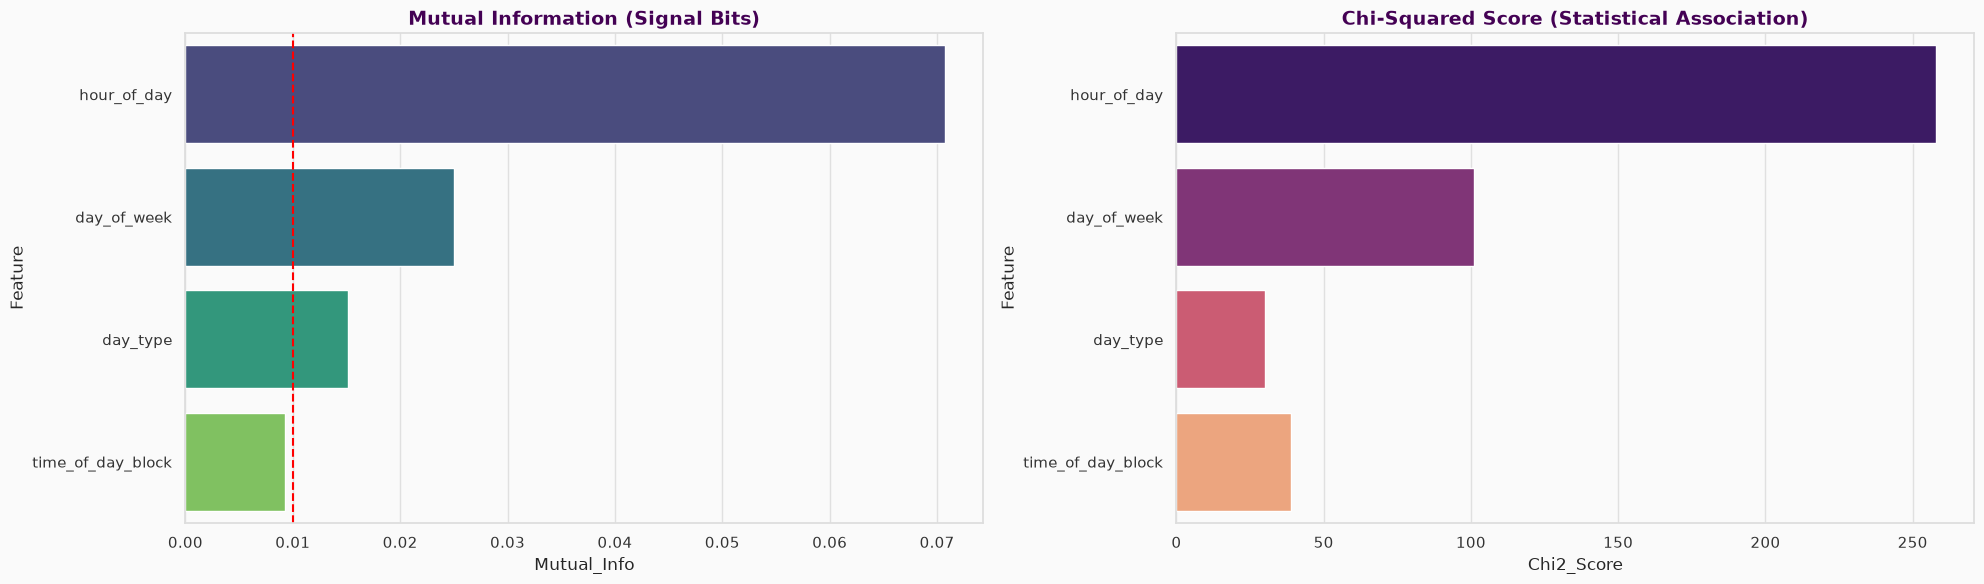

TEMPORAL RESULTS TABLE:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.015114,30.155504,3.672087e-05
2,time_of_day_block,0.009227,38.951938,7.314550e-07


In [78]:
print("Initiating the temporal feature-selection arena...")

time_competitors = [
    'hour_of_day', 
    'day_of_week',
    'time_of_day_block',
    'day_type'
]

X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# Note: 'y' is the multiclass target (reason_primary) defined in Cell 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Mutual Information (Signal Bits)", fontsize=14, fontweight='bold', color=PIENZA_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Noise Threshold')

sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Statistical Association)", fontsize=14, fontweight='bold', color=PIENZA_PURPLE)

plt.tight_layout()
plt.show()

print("TEMPORAL RESULTS TABLE:")
display(time_report)

<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

*Verdict: `hour_of_day` beats the coarser `time_of_day_block` (resolution wins), and `day_of_week` beats `day_type` (redundant loser dropped). Both survivors clear the 0.01 MI noise threshold and advance to one-hot encoding.*

</div>

#### 1.11 — Audit of the 3 context features

Evaluates product_category and driver_state_at_request in isolation for their discriminative power.

Auditing 2 features in isolation...


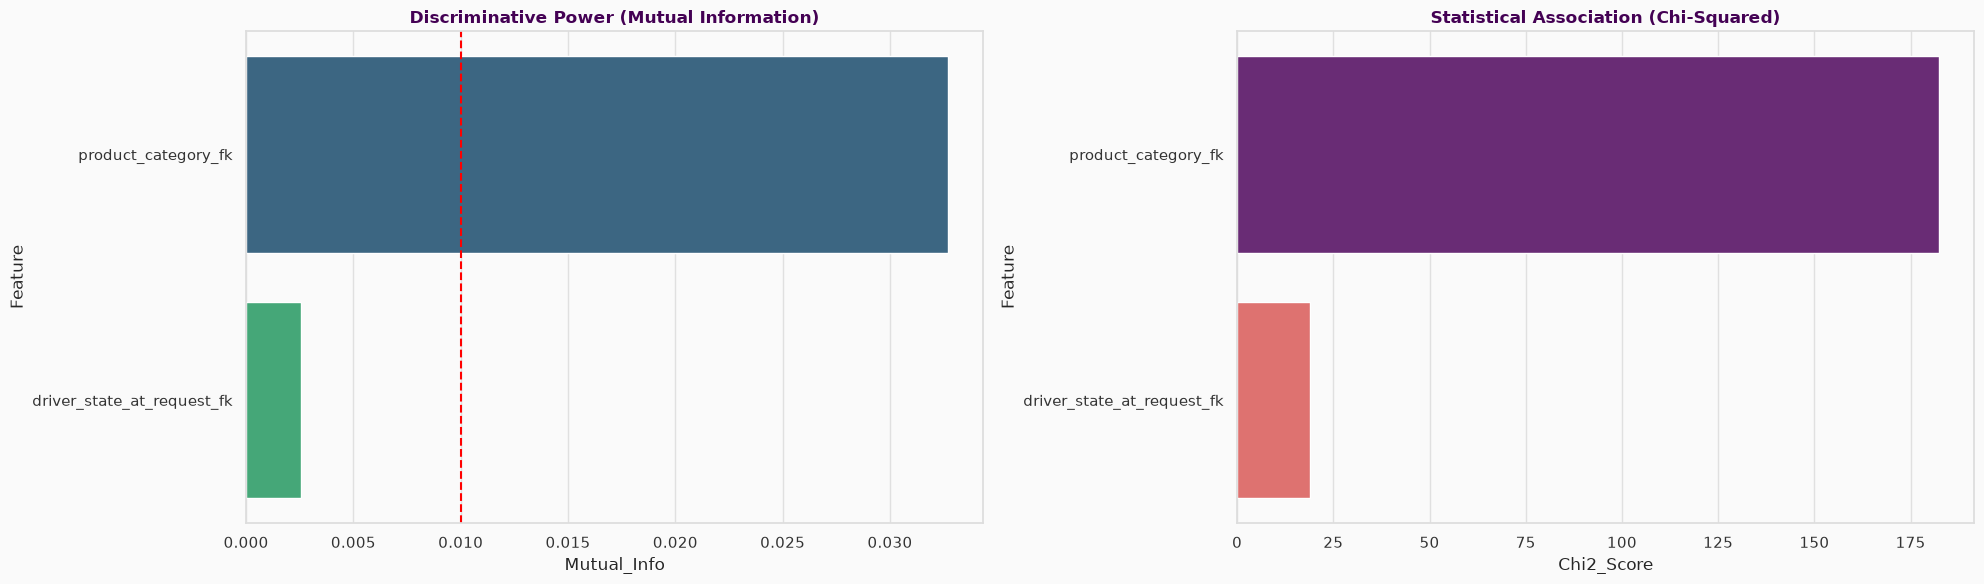

SOLO AUDIT RESULTS:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,product_category_fk,0.032699,182.354377,1.072798e-36
1,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03


In [79]:
solo_candidates = [
    'product_category_fk', # UberX, Comfort, Black
    'driver_state_at_request_fk' # Idle vs. OnTrip
]

print(f"Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

for col in solo_candidates:
    if col in df_input.columns:
        # Clean encoding (LabelEncoder treats -1/NaN as new categories)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Discriminative Power (Mutual Information)", fontweight='bold', color=PIENZA_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Noise Threshold')

sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Statistical Association (Chi-Squared)", fontweight='bold', color=PIENZA_PURPLE)

plt.tight_layout()
plt.show()

print("SOLO AUDIT RESULTS:")
display(df_solo_audit)


<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

*Verdict: `product_category_fk` clears the noise threshold (product segment shapes rejection reason); `driver_state_at_request_fk` is pure noise — a low p-value but negligible MI, so it does not help separate classes.*

</div>

#### 1.12 — Final scaling of both universes

Applies StandardScaler to the Wide and Focused universes.

In [80]:
print("Scaling Universes (StandardScaler only)...")

scaler_a = StandardScaler()
X_league_a = pd.DataFrame(
    scaler_a.fit_transform(X_a_log),
    index=X_a_log.index,
    columns=X_a_log.columns
)

scaler_b = StandardScaler()
X_league_b = pd.DataFrame(
    scaler_b.fit_transform(X_b_log),
    index=X_b_log.index,
    columns=X_b_log.columns
)

print(f"Universes Scaled. League A: {X_league_a.shape} | League B: {X_league_b.shape}")

Scaling Universes (StandardScaler only)...
Universes Scaled. League A: (4760, 41) | League B: (4760, 20)


#### 1.13 — Hybrid one-hot encoding fusion

One-hot encodes the winning categorical features and fuses them with the scaled numeric universes.

In [81]:
print("Executing Hybrid Fusion (Pure Categories, No Product Fusion)...")

candidates = [
    'final_zone_id',
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

winning_cats = [c for c in candidates if c in df_input.columns]
X_cats_final = df_input[winning_cats].copy()

for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

X_ohe = pd.get_dummies(X_cats_final, drop_first=True)
print(f"-> OHE Shape: {X_ohe.shape}")

# Uses the variables already scaled in Cell 1
X_league_a_hybrid = pd.concat([X_league_a, X_ohe], axis=1)
X_league_b_hybrid = pd.concat([X_league_b, X_ohe], axis=1)

ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Focused_Raw_Hybrid": X_league_b_hybrid
}

print(f"\nHYBRID UNIVERSES READY:")
for name, df_lig in ligas_finales.items():
    print(f"-> {name:<30} | Shape: {df_lig.shape}")

Executing Hybrid Fusion (Pure Categories, No Product Fusion)...
-> OHE Shape: (4760, 95)

HYBRID UNIVERSES READY:
-> LIGA_A_Wide_Hybrid             | Shape: (4760, 136)
-> LIGA_B_Focused_Raw_Hybrid      | Shape: (4760, 115)


#### 1.14 — Feature-name hygiene patch

Converts all column names to strings to satisfy scikit-learn's validation requirements.

In [82]:
print("Applying Feature Name Hygiene...")

for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("Feature Names are now uniform strings.")

Applying Feature Name Hygiene...
Feature Names are now uniform strings.


#### 1.15 — Temporal indexing and walk-forward folds

Assigns each row to one of 6 weekly folds and builds the walk-forward train/test splits.

In [83]:
print("Synchronizing Temporal Engine (Full Sync Mode)...")

if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

weekly_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

df_input['week_id'] = 0
for wk, start, end in weekly_schedule:
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

valid_rows_mask = df_input['week_id'] > 0

print(f"-> Dropping {len(df_input) - valid_rows_mask.sum()} out-of-schedule rows.")

df_input = df_input[valid_rows_mask].reset_index(drop=True)
y = y[valid_rows_mask]  # CRUCIAL: keep the target synchronized

if 'ligas_finales' in locals():
    for name, df_lig in ligas_finales.items():
        ligas_finales[name] = df_lig[valid_rows_mask].reset_index(drop=True)
        print(f"-> Synced {name}: {ligas_finales[name].shape}")

print("FINAL TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

custom_cv_folds = []
for i in range(1, 6):
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    test_mask = (df_input['week_id'] == i + 1)
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()
    custom_cv_folds.append((train_indices, test_indices))
    print(f"-> Fold {i}: Train W[1-{i}] vs Test W{i+1}")

print("\nTemporal Engine Fully Synchronized.")

Synchronizing Temporal Engine (Full Sync Mode)...
-> Dropping 0 out-of-schedule rows.
-> Synced LIGA_A_Wide_Hybrid: (4760, 136)
-> Synced LIGA_B_Focused_Raw_Hybrid: (4760, 115)
FINAL TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64
-> Fold 1: Train W[1-1] vs Test W2
-> Fold 2: Train W[1-2] vs Test W3
-> Fold 3: Train W[1-3] vs Test W4
-> Fold 4: Train W[1-4] vs Test W5
-> Fold 5: Train W[1-5] vs Test W6

Temporal Engine Fully Synchronized.


## Phase 2 — Layer 1 (Triage Classifier)

Trains and validates the first-stage XGBoost classifier that filters out low-value/non-operational noise, passing the ambiguous remainder through to Layer 2.

#### 2.1 — Layer 1 target and feature foundry

Builds the Layer 1 target (triage categories) and its feature matrix from the Focused universe.

In [84]:
print("Forging Layer 1: Target & Features...")

def map_layer1_target(val):
    if val == 1: return "Dropoff: Non-Operational"
    if val == 2: return "Dropoff: Proxy Zone"
    if val == 3: return "Low Profitability"
    if val == 4: return "Long Pickup Time"
    return "THE_NUANCED_REST"

y_L1_text = df_input['reason_primary_fk'].fillna(9999).apply(map_layer1_target)

le_L1 = LabelEncoder()
y_L1 = le_L1.fit_transform(y_L1_text)

print(f"Target y_L1 created. Classes: {list(le_L1.classes_)}")

numeric_L1 = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'traffic_index_base_120', 'time_since_last_offer',
    'eph_operational_index', 'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]
categorical_L1 = [
    'product_category_fk', 'hour_of_day', 'day_of_week', 'final_zone_id'
]

X_num_L1 = df_input[numeric_L1].copy()
for col in ['historical_rolling_avg_traffic_index', 'traffic_volatility_index_ml']:
    X_num_L1[col] = pd.to_numeric(X_num_L1[col], errors='coerce')
X_num_L1 = X_num_L1.fillna(0)

X_cat_L1 = df_input[categorical_L1].copy()
X_cat_L1['product_category_fk'] = X_cat_L1['product_category_fk'].astype(str)
X_cat_L1 = X_cat_L1.fillna("N/A")

X_cat_encoded_L1 = pd.get_dummies(X_cat_L1, drop_first=True)

X_L1 = pd.concat([X_num_L1, X_cat_encoded_L1], axis=1)

regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_L1.columns = [
    regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col
    for col in X_L1.columns
]

print(f"Matrix X_L1 built. Shape: {X_L1.shape}")
print("-" * 60)
print("Class distribution (Layer 1):")
print(y_L1_text.value_counts(normalize=True))

Forging Layer 1: Target & Features...
Target y_L1 created. Classes: ['Dropoff: Non-Operational', 'Dropoff: Proxy Zone', 'Long Pickup Time', 'Low Profitability', 'THE_NUANCED_REST']
Matrix X_L1 built. Shape: (4760, 103)
------------------------------------------------------------
Class distribution (Layer 1):
reason_primary_fk
Dropoff: Non-Operational    0.497059
THE_NUANCED_REST            0.199790
Low Profitability           0.176050
Long Pickup Time            0.076891
Dropoff: Proxy Zone         0.050210
Name: proportion, dtype: float64


#### 2.2 — Layer 1 model comparison (stratified CV)

Cross-validates the baseline XGBoost model for Layer 1 with class-balanced sample weights.

In [85]:
print("Initiating Layer 1 model comparison...")
print("-> Mission: High-Precision Triage (Non-Op, Low-Profit, Long-Pickup)")

tournament_mask = df_input['week_id'].isin([1, 2, 3, 4, 5])
X_L1_train = X_L1[tournament_mask]
y_L1_train = y_L1[tournament_mask]

print(f"-> Training Pool: {len(X_L1_train)} samples.")

# Counteract the 7.7% class imbalance
l1_sample_weights = compute_sample_weight(class_weight='balanced', y=y_L1_train)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# max_depth=6 to capture the complex geographic/economic rules
model_L1 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

print("Training Layer 1 Model...")
cv_results = cross_validate(
    model_L1,
    X_L1_train,
    y_L1_train,
    cv=skf,
    scoring=scoring,
    params={'sample_weight': l1_sample_weights},
    n_jobs=-1
)

print("\n" + "="*70)
print("LAYER 1 PERFORMANCE CARD (STRATIFIED CV)")
print("="*70)
print(f"F1-MACRO: {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")
print(f"PRECISION: {cv_results['test_precision_macro'].mean():.4f}")
print(f"RECALL: {cv_results['test_recall_macro'].mean():.4f}")
print("-" * 70)

best_L1_score = cv_results['test_f1_macro'].mean()
print(f"Layer 1 Baseline established at {best_L1_score:.4f}")

Initiating Layer 1 model comparison...
-> Mission: High-Precision Triage (Non-Op, Low-Profit, Long-Pickup)
-> Training Pool: 3980 samples.
Training Layer 1 Model...

LAYER 1 PERFORMANCE CARD (STRATIFIED CV)
F1-MACRO: 0.7998 (+/- 0.0087)
PRECISION: 0.7779
RECALL: 0.8322
----------------------------------------------------------------------
Layer 1 Baseline established at 0.7998


#### 2.3 — Purge, split, and chronological isolation

Locks in the walk-forward train/test split and frees memory from unused feature universes.

In [86]:
print("Executing Purge and Final Chronological Split...")

X_final = ligas_finales['LIGA_B_Focused_Raw_Hybrid'].copy()

# Requires 'week_id' from the original df_input
if 'week_id' not in df_input.columns:
    raise ValueError("CRITICAL ERROR: 'week_id' not found. Run Cell 1.5 first.")

CUTOFF_WEEK = 5 # Train on Weeks 1-5, test on Week 6.

train_mask = df_input['week_id'] <= CUTOFF_WEEK
test_mask = df_input['week_id'] > CUTOFF_WEEK

# No random train_test_split — time is the split boundary.
X_train = X_final[train_mask]
X_test = X_final[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

vars_to_purge = ['X_wide_pca', 'X_focused_pca', 'X_league_a_hybrid', 'X_league_c_hybrid']
for var in vars_to_purge:
    if var in locals():
        del globals()[var]

print("Losing leagues purged. RAM freed.")

print(f"\nFinal Dataset Locked (League B, Raw Hybrid).")
print(f"-> Strategy: Walk-Forward (Train: W1-{CUTOFF_WEEK} | Test: W{CUTOFF_WEEK+1})")
print(f"-> X_train Shape: {X_train.shape} (Historical)")
print(f"-> X_test Shape: {X_test.shape} (Immediate Future)")

if len(set(X_train.index).intersection(set(X_test.index))) == 0:
    print("INTEGRITY VERIFIED: No data leakage between Train and Test.")
else:
    print("ALERT: Shared indices found. Review the cutoff.")

Executing Purge and Final Chronological Split...
Losing leagues purged. RAM freed.

Final Dataset Locked (League B, Raw Hybrid).
-> Strategy: Walk-Forward (Train: W1-5 | Test: W6)
-> X_train Shape: (3980, 115) (Historical)
-> X_test Shape: (780, 115) (Immediate Future)
INTEGRITY VERIFIED: No data leakage between Train and Test.


#### 2.4 — Layer 1 tuning

Randomized hyperparameter search for the Layer 1 model, cached to disk.

In [87]:
_CACHE_PATH_L1 = os.path.join(DUMP_DIR, "0509_l1_bouncer_champion.joblib")

if os.path.exists(_CACHE_PATH_L1) and not FORCE_UPDATE:
    print(f"Cache found — loading Layer 1 champion from {_CACHE_PATH_L1}")
    search_L1 = joblib.load(_CACHE_PATH_L1)
    model_champion_L1 = search_L1.best_estimator_
    print(f"Best F1-Macro (L1): {search_L1.best_score_:.4f}")
    print(f"Params: {search_L1.best_params_}")
else:
    print("STARTING STRATIFIED TUNING: LAYER 1...")

    X_train_L1 = X_L1[tournament_mask].copy()
    y_train_L1 = y_L1[tournament_mask]
    print(f"-> Data available for tuning (W1-5): {len(X_train_L1)} samples.")

    l1_tuning_weights = compute_sample_weight(class_weight='balanced', y=y_train_L1)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    param_dist = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [4, 5, 6, 7],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.5, 1, 2],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    }

    xgb_l1 = xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )

    search_L1 = RandomizedSearchCV(
        estimator=xgb_l1,
        param_distributions=param_dist,
        n_iter=20,
        scoring='f1_macro',
        cv=skf,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        error_score=0
    )

    start_time = time.time()
    print(f"Searching for the optimal Triage configuration on {X_train_L1.shape}...")
    search_L1.fit(X_train_L1, y_train_L1, sample_weight=l1_tuning_weights)
    elapsed = time.time() - start_time

    model_champion_L1 = search_L1.best_estimator_

    joblib.dump(search_L1, _CACHE_PATH_L1)
    print(f"\nTUNING COMPLETE in {elapsed:.1f}s — cached to {_CACHE_PATH_L1}")
    print(f"Best Score (F1-Macro): {search_L1.best_score_:.4f}")
    print(f"BEST L1 HYPERPARAMETERS:\n{search_L1.best_params_}")
    print("Variable 'model_champion_L1' ready for the Triage mission.")

Cache found — loading Layer 1 champion from /workspaces/pienza/data/dumped_files/0509_l1_bouncer_champion.joblib
Best F1-Macro (L1): 0.8321
Params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.7}


#### 2.5 — Layer 1 validation curve

Validation curve over max_depth to check for over/underfitting.

Loading validation curve from cache...
Cache loaded.


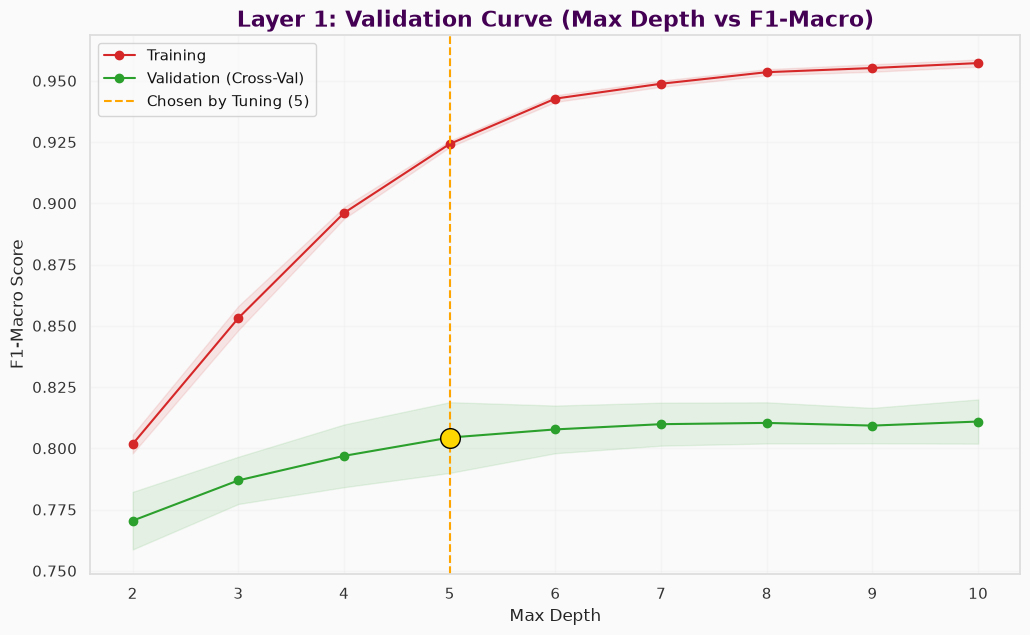

Gap analysis at Depth=5: 0.1198


In [88]:
_CACHE_PATH = os.path.join(DUMP_DIR, "0509X_l1_validation_curve.joblib")

if os.path.exists(_CACHE_PATH) and not FORCE_UPDATE:
    print("Loading validation curve from cache...")
    _cache = joblib.load(_CACHE_PATH)
    train_scores = _cache["train_scores"]
    test_scores = _cache["test_scores"]
    param_range = _cache["param_range"]
    print("Cache loaded.")
else:
    print("Calculating Validation Curve with Sample Weights (Manual Mode)...")

    param_range = np.arange(2, 11)
    best_params = search_L1.best_params_.copy()
    if 'max_depth' in best_params:
        del best_params['max_depth']

    model_audit = xgb.XGBClassifier(
        **best_params,
        objective='multi:softprob',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )

    train_scores, test_scores = validation_curve(
        model_audit,
        X_train_L1,
        y_train_L1,
        param_name="max_depth",
        param_range=param_range,
        cv=skf,
        scoring="f1_macro",
        n_jobs=-1,
        params={'sample_weight': l1_tuning_weights}
    )

    joblib.dump({"train_scores": train_scores, "test_scores": test_scores, "param_range": param_range}, _CACHE_PATH)
    print(f"Validation curve computed and saved: {_CACHE_PATH}")

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 7))
plt.plot(param_range, train_mean, label="Training", color="#d62728", marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")
plt.plot(param_range, test_mean, label="Validation (Cross-Val)", color="#2ca02c", marker='o')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")
plt.axvline(x=5, color='orange', linestyle='--', label='Chosen by Tuning (5)')
plt.scatter(5, test_mean[param_range == 5], s=200, color='gold', edgecolor='black', zorder=5)
plt.title("Layer 1: Validation Curve (Max Depth vs F1-Macro)", fontsize=16, fontweight='bold', color=PIENZA_PURPLE)
plt.xlabel("Max Depth")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.2)
plt.show()

print(f"Gap analysis at Depth=5: {train_mean[param_range==5][0] - test_mean[param_range==5][0]:.4f}")

#### 2.6 — Class mapping and immutable indexing

Locks the mapping between model class indices and strategic categories to avoid index bugs in threshold logic.

In [89]:
print("AUDITING LAYER 1: CLASS INDEX MAPPING...")
print("-" * 80)

# 1. Recover the alphabetical order LabelEncoder imposed
l1_classes = le_L1.classes_

# Instead of hardcoding class indices, build named variables that always point to the right class
# Instead of hardcoding '2', use these variables which always point to the right class
try:
    IDX_NUANCED = np.where(l1_classes == "THE_NUANCED_REST")[0][0]
    IDX_LONG_PICK = np.where(l1_classes == "Long Pickup Time")[0][0]
    IDX_LOW_PROFIT = np.where(l1_classes == "Low Profitability")[0][0]
    IDX_NON_OP = np.where(l1_classes == "Dropoff: Non-Operational")[0][0]

    print("Status: strategic indices mapped and locked.")
except IndexError as e:
    print(f"ERROR: one of the strategic classes was not found in le_L1.classes_: {e}")

audit_data = []
for i, name in enumerate(l1_classes):
    count = np.sum(y_L1 == i)
    audit_data.append({
        "Model Index": i,
        "Global Variable": f"IDX_...",
        "Strategic Category": name,
        "Samples (N)": count
    })

df_l1_audit = pd.DataFrame(audit_data)
display(df_l1_audit)

print("-" * 80)
print(f"ACCESS CONTROL: the gate to Layer 2 is Index [{IDX_NUANCED}].")

AUDITING LAYER 1: CLASS INDEX MAPPING...
--------------------------------------------------------------------------------
Status: strategic indices mapped and locked.


,Model Index,Global Variable,Strategic Category,Samples (N)
0,0,IDX_...,Dropoff: Non-Operational,2366
1,1,IDX_...,Dropoff: Proxy Zone,239
2,2,IDX_...,Long Pickup Time,366
3,3,IDX_...,Low Profitability,838
4,4,IDX_...,THE_NUANCED_REST,951


--------------------------------------------------------------------------------
ACCESS CONTROL: the gate to Layer 2 is Index [4].


#### 2.7 — Threshold-rescue setup

Recovers the test set and predictions if missing, and defines the shared Pienza color palette for the plots that follow.

In [90]:
print("Preparing Layer 1's decision engine...")


# --- 0.2 DATA RECOVERY GUARD (in case of a kernel restart) ---
if 'y_L1_test' not in locals() or 'X_L1_test' not in locals():
    print("Empty memory: recovering X_L1_test and y_L1_test (Week 6)...")
    test_mask = (df_input['week_id'] == 6)
    X_L1_test = X_L1[test_mask]
    y_L1_test = y_L1[test_mask]

# Generate probabilities & predictions if not already in memory
if 'y_probs_L1' not in locals() or 'y_pred_L1' not in locals() or len(y_probs_L1) != len(X_L1_test):
    print("Computing predict() and predict_proba() for Layer 1...")
    y_probs_L1 = model_champion_L1.predict_proba(X_L1_test)
    y_pred_L1 = model_champion_L1.predict(X_L1_test)

try:
    nuanced_idx = np.where(le_L1.classes_ == "THE_NUANCED_REST")[0][0]
except IndexError:
    nuanced_idx = IDX_NUANCED if 'IDX_NUANCED' in locals() else 4
    print(f"Using fallback for nuanced_idx: {nuanced_idx}")

Preparing Layer 1's decision engine...


#### 2.8 — Classification report and confusion matrix

Reports Layer 1's classification performance and plots the confusion matrix heatmap.


LAYER 1: CLASSIFICATION REPORT
                          precision    recall  f1-score   support

        THE_NUANCED_REST       0.71      0.69      0.70       164
        Long Pickup Time       0.50      0.96      0.66        56
       Low Profitability       0.69      0.74      0.72       128
Dropoff: Non-Operational       0.95      0.81      0.88       391
     Dropoff: Proxy Zone       0.81      0.85      0.83        41

                accuracy                           0.79       780
               macro avg       0.73      0.81      0.76       780
            weighted avg       0.82      0.79      0.80       780



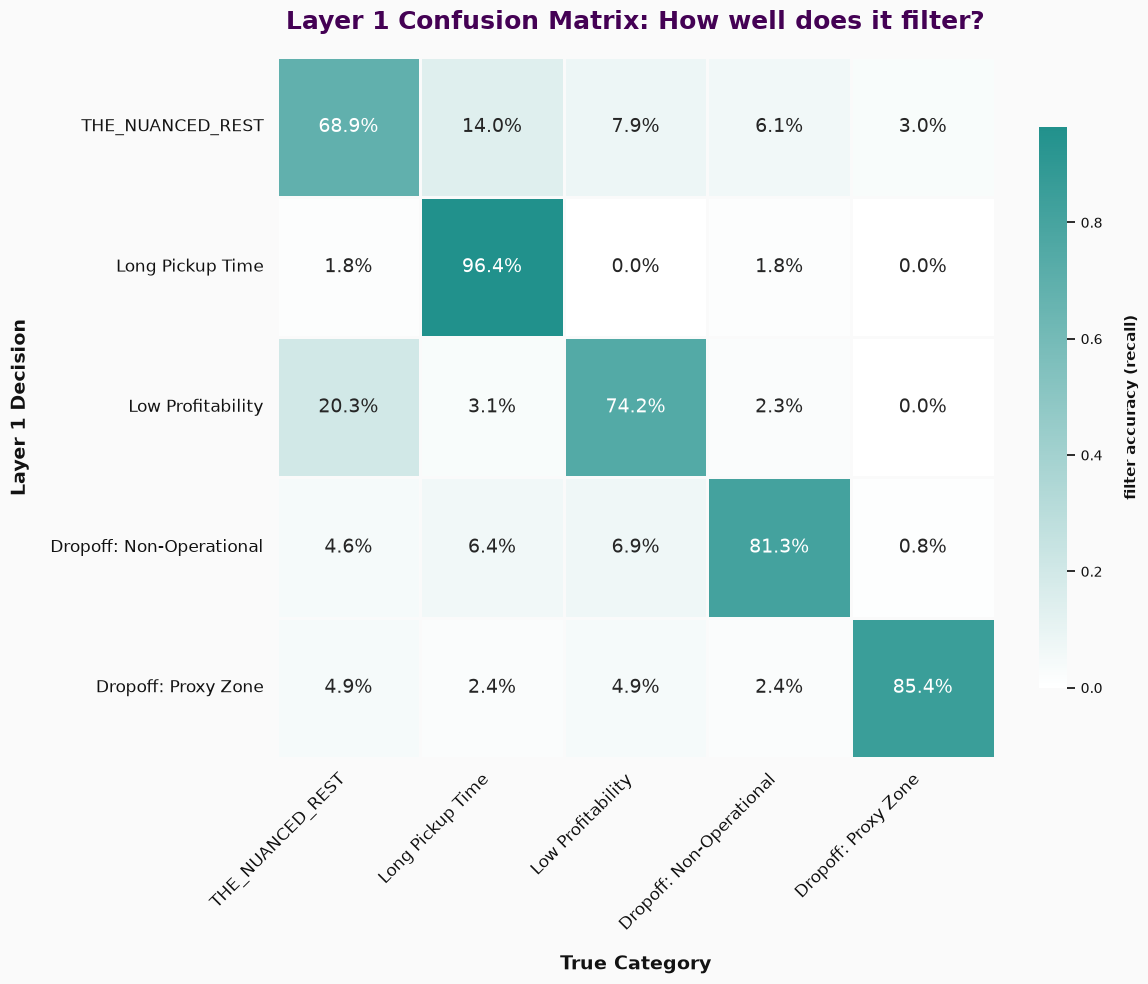


OPERATIONAL SUMMARY:
-> Layer 1 passed 160 offers through to Layer 2 (20.5% of traffic).
-> Noise reduction achieved: 79.5%


In [91]:
desired_order = [
    "THE_NUANCED_REST",
    "Long Pickup Time",
    "Low Profitability",
    "Dropoff: Non-Operational",
    "Dropoff: Proxy Zone"
]

ordered_indices = le_L1.transform(desired_order)

print("\n" + "="*80)
print("LAYER 1: CLASSIFICATION REPORT")
print("="*80)
# 'labels' forces the row order
print(classification_report(
    y_L1_test,
    y_pred_L1,
    labels=ordered_indices,
    target_names=desired_order,
    zero_division=0
))

# 'labels' forces the row/column order in the matrix
cm = confusion_matrix(y_L1_test, y_pred_L1, labels=ordered_indices, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10), facecolor=PIENZA_GREY)
ax.set_facecolor(PIENZA_GREY)

sns.heatmap(
    cm,
    annot=True,
    fmt=".1%",
    cmap=cmap_pienza,
    xticklabels=desired_order,
    yticklabels=desired_order,
    cbar_kws={'shrink': 0.8, 'label': 'filter accuracy (recall)'},
    linewidths=2,
    linecolor=PIENZA_GREY,
    ax=ax,
    annot_kws={"size": 14}
)

ax.set_title("Layer 1 Confusion Matrix: How well does it filter?",
             fontsize=18, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("True Category", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
ax.set_ylabel("Layer 1 Decision", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=12, color=PIENZA_TEXT, fontweight='500')
plt.yticks(rotation=0, fontsize=12, color=PIENZA_TEXT, fontweight='500')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10, colors=PIENZA_TEXT)
cbar.set_label('filter accuracy (recall)', size=11, weight='bold', color=PIENZA_TEXT, labelpad=15)

plt.tight_layout()
plt.show()

try:
    # First index of our desired order is THE_NUANCED_REST
    nuanced_label_idx = ordered_indices[0]
    n_passed = (y_pred_L1 == nuanced_label_idx).sum()
    pass_rate = (n_passed / len(y_L1_test)) * 100

    print(f"\nOPERATIONAL SUMMARY:")
    print(f"-> Layer 1 passed {n_passed} offers through to Layer 2 ({pass_rate:.1f}% of traffic).")
    print(f"-> Noise reduction achieved: {100 - pass_rate:.1f}%")
except Exception as e:
    print(f"Calculation Note: {e}")

#### 2.9 — Threshold-rescue detail and scorecard

Applies a probability threshold to rescue nuanced cases, then reports the resulting global scorecard.

Preparing Layer 1's decision engine...
Layer 1 active: analyzing global impact with T=0.4


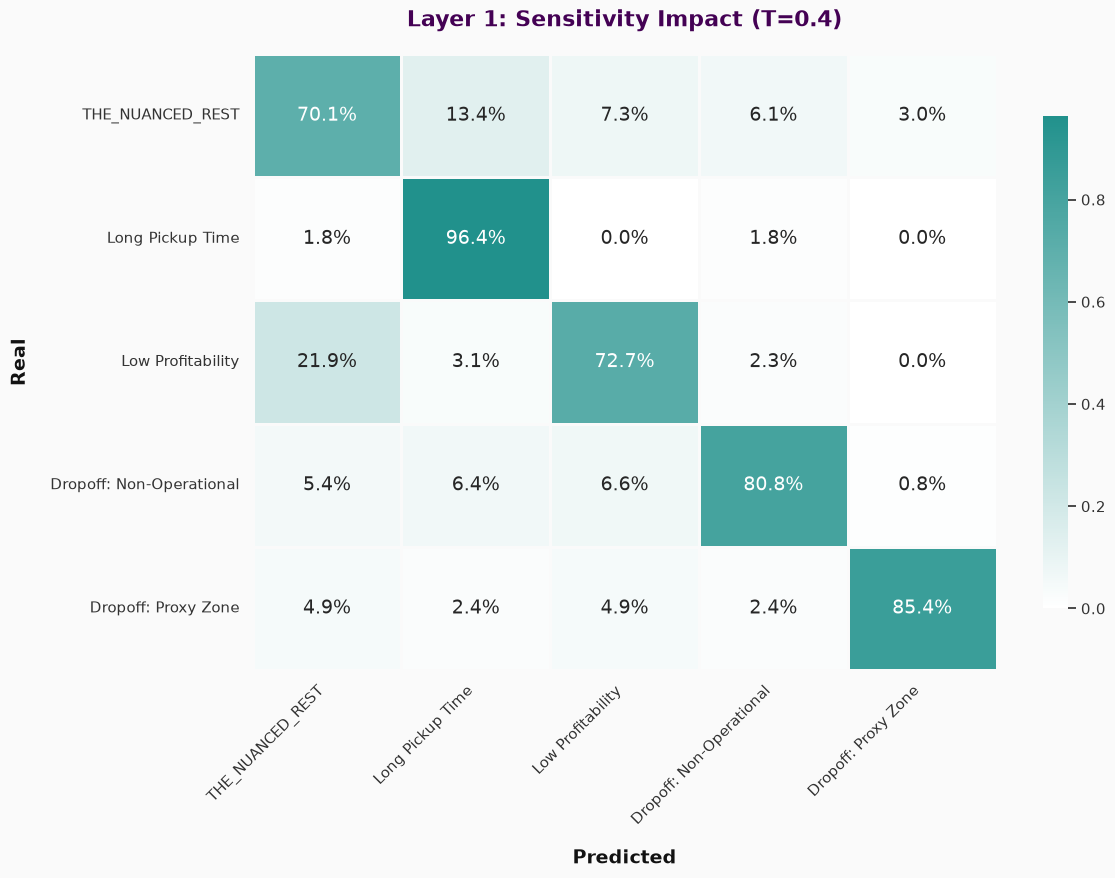


GLOBAL PERFORMANCE SCORECARD (L1 AFTER RESCUE)
Metric                    | Value     
----------------------------------------
Precision (Nuanced)       |      68.9%
Recall (Nuanced)          |      70.1%
F1-Score (Nuanced)        |      69.5%
----------------------------------------
F1-Macro (Global)         |      75.7%
Total Accuracy            |      78.6%
----------------------------------------
-> Rescues executed: 7

DETAIL BY CATEGORY:
                          precision    recall  f1-score   support

        THE_NUANCED_REST       0.69      0.70      0.69       164
        Long Pickup Time       0.51      0.96      0.67        56
       Low Profitability       0.70      0.73      0.71       128
Dropoff: Non-Operational       0.95      0.81      0.88       391
     Dropoff: Proxy Zone       0.81      0.85      0.83        41

                accuracy                           0.79       780
               macro avg       0.73      0.81      0.76       780
            weighted 

In [92]:
print("Preparing Layer 1's decision engine...")

if 'y_probs_L1' not in locals() or len(y_probs_L1) != len(X_L1_test):
    print("Computing predict_proba() for Layer 1...")
    y_probs_L1 = model_champion_L1.predict_proba(X_L1_test)

try:
    nuanced_idx = np.where(le_L1.classes_ == "THE_NUANCED_REST")[0][0]
except IndexError:
    nuanced_idx = IDX_NUANCED if 'IDX_NUANCED' in locals() else 4
    print(f"Using fallback for nuanced_idx: {nuanced_idx}")

t_nuanced = 0.40 # <--- ADJUST THIS (try 0.15 for max recall)

y_pred_balanced = []
rescues = 0

print(f"Layer 1 active: analyzing global impact with T={t_nuanced}")

for prob_vector in y_probs_L1:
    idx_natural = np.argmax(prob_vector)
    p_nuanced = prob_vector[nuanced_idx]

    # If confidence in THE_NUANCED_REST clears the threshold, force the prediction
    if p_nuanced >= t_nuanced:
        final_idx = nuanced_idx
    else:
        final_idx = idx_natural

    if final_idx != idx_natural:
        rescues += 1
    y_pred_balanced.append(final_idx)

desired_order = [
    "THE_NUANCED_REST",
    "Long Pickup Time",
    "Low Profitability",
    "Dropoff: Non-Operational",
    "Dropoff: Proxy Zone"
]
ordered_indices = le_L1.transform(desired_order)

# labels=ordered_indices forces the order in the matrix
cm = confusion_matrix(y_L1_test, y_pred_balanced, labels=ordered_indices, normalize='true')
fig, ax = plt.subplots(figsize=(12, 8), facecolor=PIENZA_GREY)

sns.heatmap(
    cm, annot=True, fmt=".1%", cmap=cmap_pienza,
    xticklabels=desired_order, yticklabels=desired_order,
    cbar_kws={'shrink': 0.8}, linewidths=2, linecolor=PIENZA_GREY, ax=ax,
    annot_kws={"size": 14}
)

ax.set_title(f"Layer 1: Sensitivity Impact (T={t_nuanced})",
             fontsize=16, fontweight='bold', color=PIENZA_PURPLE, pad=20)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel("Predicted", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
ax.set_ylabel("Real", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
plt.show()

print("\n" + "="*70)
print("GLOBAL PERFORMANCE SCORECARD (L1 AFTER RESCUE)")
print("="*70)

report = classification_report(
    y_L1_test,
    y_pred_balanced,
    labels=ordered_indices,
    target_names=desired_order,
    output_dict=True,
    zero_division=0
)

f1_macro = report['macro avg']['f1-score']
acc = accuracy_score(y_L1_test, y_pred_balanced)

# NOTE: since cm was reordered, THE_NUANCED_REST is now row/column 0
nuanced_cm_idx = 0
nuanced_recall = cm[nuanced_cm_idx, nuanced_cm_idx]

print(f"{'Metric':<25} | {'Value':<10}")
print("-" * 40)
print(f"{'Precision (Nuanced)':<25} | {report['THE_NUANCED_REST']['precision']:>10.1%}")
print(f"{'Recall (Nuanced)':<25} | {nuanced_recall:>10.1%}")
print(f"{'F1-Score (Nuanced)':<25} | {report['THE_NUANCED_REST']['f1-score']:>10.1%}")
print("-" * 40)
print(f"{'F1-Macro (Global)':<25} | {f1_macro:>10.1%}")
print(f"{'Total Accuracy':<25} | {acc:>10.1%}")
print("-" * 40)
print(f"-> Rescues executed: {rescues}")

print("\nDETAIL BY CATEGORY:")
print(classification_report(
    y_L1_test,
    y_pred_balanced,
    labels=ordered_indices,
    target_names=desired_order,
    zero_division=0
))

#### 2.10 — SHAP signal analysis

Computes SHAP values for the nuanced class and visualizes the top directional feature drivers.

Forging the Nuanced Signal DNA Atlas with Semantic Labels...


/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


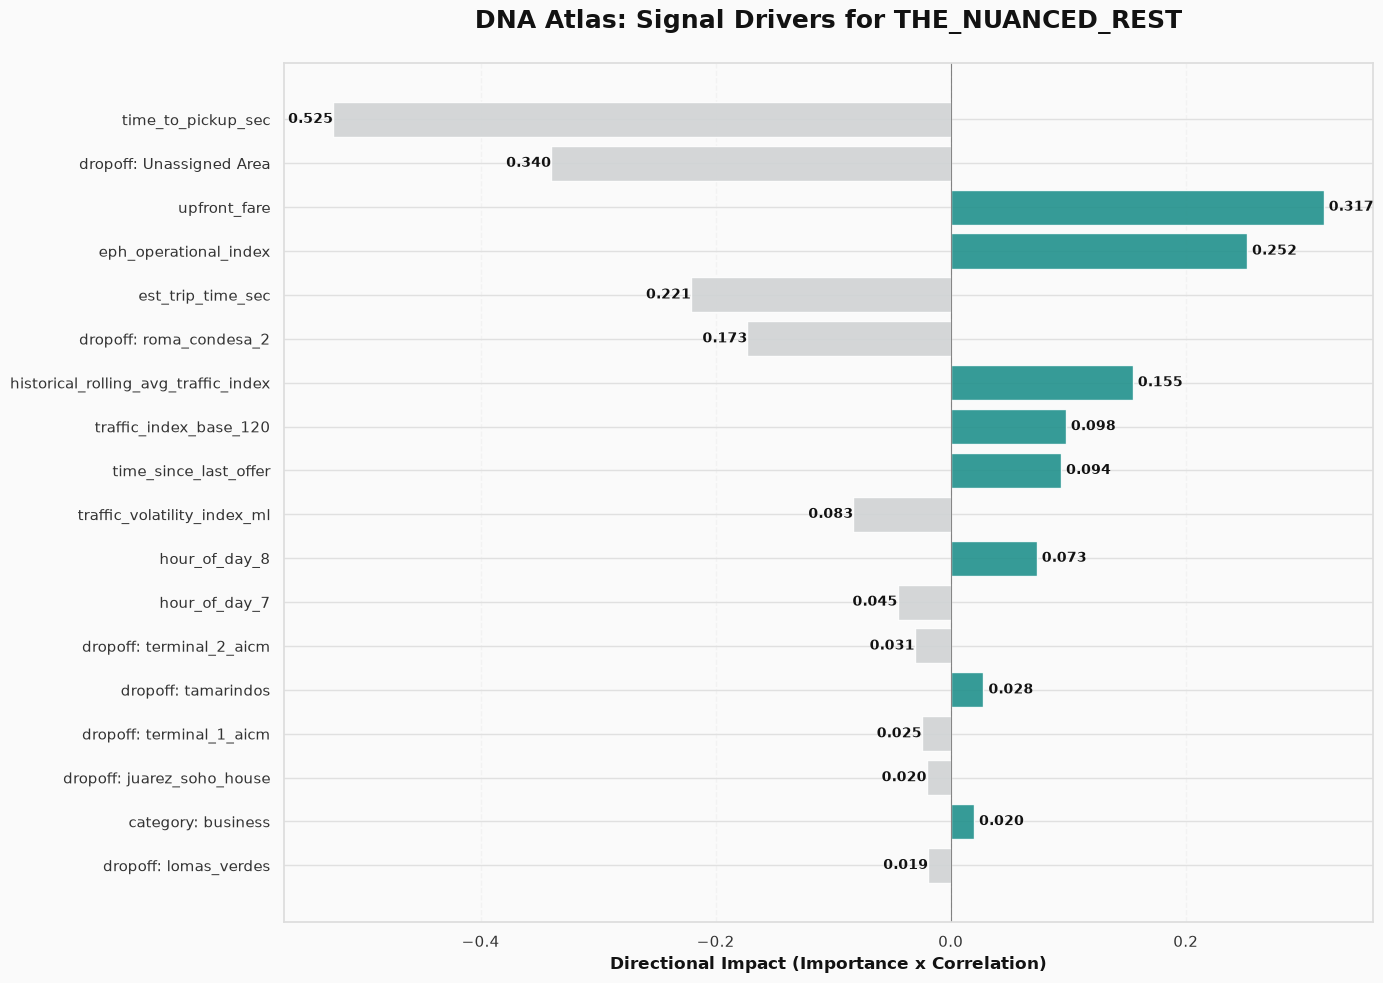

In [93]:
print("Forging the Nuanced Signal DNA Atlas with Semantic Labels...")

POSITIVE_COLOR = "#21918c"
NEGATIVE_COLOR = "#D0D3D4"

zone_dict = globals().get('zone_map', {})
prod_dict = globals().get('product_map', {})

def map_feature_human_readable(feature_name):
    """Translates technical column names into semantic labels."""
    s_feat = str(feature_name)

    if 'product_category_fk_' in s_feat:
        raw_id = s_feat.split('product_category_fk_')[-1]
        try:
            val = int(float(raw_id))
            if val in prod_dict:
                p_name = prod_dict[val]
                # LOCAL OVERRIDE: business_comfort -> business
                if p_name == 'business_comfort': p_name = 'business'
                return f"category: {p_name}"
        except: pass
        if raw_id in prod_dict:
            p_name = prod_dict[raw_id]
            # LOCAL OVERRIDE: business_comfort -> business
            if p_name == 'business_comfort': p_name = 'business'
            return f"category: {p_name}"

    prefixes = ['final_zone_id_', 'final_zone_', 'dest_id_']
    for prefix in prefixes:
        if prefix in s_feat:
            # Extract the ID (handles formats like P_1 or C_1)
            raw_id = s_feat.split(prefix)[-1]
            clean_id = raw_id.replace('P_', '').replace('C_', '')
            try:
                int_id = int(float(clean_id))
                if int_id in zone_dict: return f"dropoff: {zone_dict[int_id]}"
            except: pass
            if raw_id in zone_dict: return f"dropoff: {zone_dict[raw_id]}"

    return feature_name

target_model = model_champion_L1
target_data = X_L1_test
nuanced_class_name = "THE_NUANCED_REST"  # reverted to original

try:
    nuanced_idx = np.where(le_L1.classes_ == nuanced_class_name)[0][0]
except:
    nuanced_idx = 0
    print("Warning: Nuanced label not found. Check le_L1 classes.")

# XGBoost 3.x stores base_score as a vector-string; SHAP calls float() on it and crashes.
# Patch builtins.float temporarily to extract the first scalar from the vector string.
_orig_float = builtins.float
def _vec_safe_float(x):
    if isinstance(x, str) and x.startswith('['):
        x = _re.search(r'[+-]?[\d.]+(?:E[+-]?\d+)?', x).group()
    return _orig_float(x)

if 'explainer_L1' not in locals():
    builtins.float = _vec_safe_float
    try:
        explainer_L1 = shap.TreeExplainer(target_model)
        shap_values_L1 = explainer_L1.shap_values(target_data, check_additivity=False)
    finally:
        builtins.float = _orig_float

if isinstance(shap_values_L1, list):
    nuanced_shap = shap_values_L1[nuanced_idx]
else:
    nuanced_shap = shap_values_L1[:, :, nuanced_idx]

feature_importance = np.mean(np.abs(nuanced_shap), axis=0)
correlations = []
for i in range(nuanced_shap.shape[1]):
    feat_val = target_data.iloc[:, i]
    s_val = nuanced_shap[:, i]
    if np.std(feat_val) < 1e-9: corr = 0
    else: corr = np.corrcoef(feat_val, s_val)[0, 1]
    correlations.append(corr)

directional_impact = feature_importance * np.sign(correlations)

mapped_features = [map_feature_human_readable(col) for col in target_data.columns]

df_viz = pd.DataFrame({
    'Feature': mapped_features,
    'Importance': feature_importance,
    'Impact': directional_impact
}).sort_values(by='Importance', ascending=False).head(18)

df_viz['Color'] = df_viz['Impact'].apply(lambda x: POSITIVE_COLOR if x > 0 else NEGATIVE_COLOR)
df_viz = df_viz.iloc[::-1]

fig, ax = plt.subplots(figsize=(14, 10), facecolor="#FAFAFA")
ax.set_facecolor("#FAFAFA")

bars = ax.barh(df_viz['Feature'], df_viz['Impact'], color=df_viz['Color'], alpha=0.9, edgecolor='white')
ax.axvline(0, color=PIENZA_TEXT, linewidth=0.8, alpha=0.5)

ax.set_title(f"DNA Atlas: Signal Drivers for {nuanced_class_name}", fontsize=18, fontweight='bold', color=PIENZA_TEXT, pad=25)
ax.set_xlabel("Directional Impact (Importance x Correlation)", fontsize=12, fontweight='bold', color=PIENZA_TEXT)
ax.grid(axis='x', linestyle='--', alpha=0.3)

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f' {abs(width):.3f}',
            va='center', ha='left' if width > 0 else 'right',
            fontsize=10, fontweight='bold', color=PIENZA_TEXT)

plt.tight_layout()
plt.show()

#### 2.11 — Learning curve diagnostic

Learning curve for the Layer 1 model to check for over/underfitting as training size grows.

Cache found — loading learning curve from /workspaces/pienza/data/dumped_files/0509_l1_learning_curve.joblib


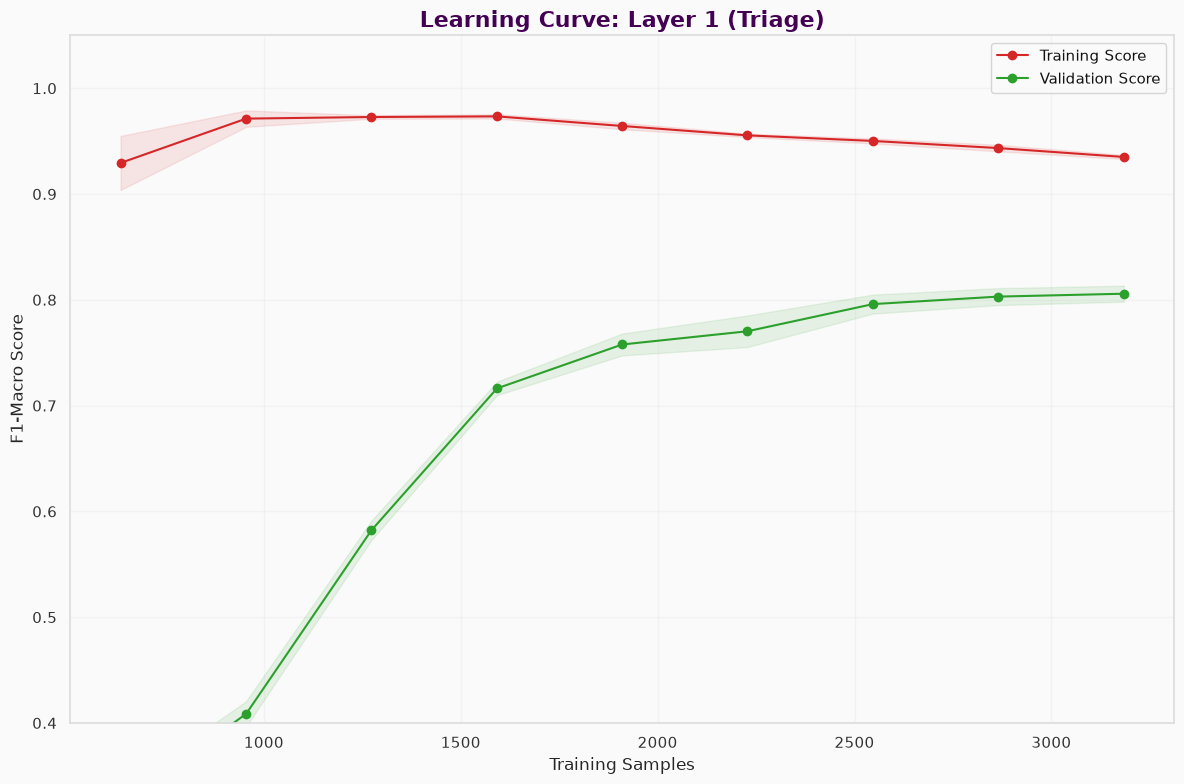

FINAL DIAGNOSIS:
-> Final Validation Score: 0.8058
-> Gap (Overfitting): 0.1293
STATUS: OPTIMAL. Layer 1 generalizes correctly.


In [94]:
_CACHE_LC_L1 = os.path.join(DUMP_DIR, "0509_l1_learning_curve.joblib")

if os.path.exists(_CACHE_LC_L1) and not FORCE_UPDATE:
    print(f"Cache found — loading learning curve from {_CACHE_LC_L1}")
    _lc = joblib.load(_CACHE_LC_L1)
    train_sizes = _lc["train_sizes"]
    train_scores = _lc["train_scores"]
    test_scores = _lc["test_scores"]
else:
    print("Generating the Learning Curve for Layer 1...")

    X_curve = X_train_L1.copy()
    y_curve = y_train_L1

    regex = re.compile(r"\[|\]|<", re.IGNORECASE)
    X_curve.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_curve.columns]

    cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes_cfg = np.linspace(0.1, 1.0, 10)

    train_sizes, train_scores, test_scores = learning_curve(
        model_champion_L1,
        X_curve, y_curve,
        cv=cv_lc,
        scoring='f1_macro',
        n_jobs=-1,
        train_sizes=train_sizes_cfg,
        random_state=42
    )

    joblib.dump({"train_sizes": train_sizes, "train_scores": train_scores, "test_scores": test_scores}, _CACHE_LC_L1)
    print(f"Cached to {_CACHE_LC_L1}")

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 8))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="#2ca02c", label="Validation Score")
plt.title("Learning Curve: Layer 1 (Triage)", fontsize=16, fontweight='bold', color=PIENZA_PURPLE)
plt.xlabel("Training Samples")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - test_mean[-1]
print(f"FINAL DIAGNOSIS:")
print(f"-> Final Validation Score: {test_mean[-1]:.4f}")
print(f"-> Gap (Overfitting): {gap:.4f}")

if test_mean[-1] < 0.70:
    print("ALERT: Layer 1 is underfitting. Needs more Triage features.")
elif gap > 0.15:
    print("ALERT: Layer 1 is memorizing cases (overfitting). Needs more regularization.")
else:
    print("STATUS: OPTIMAL. Layer 1 generalizes correctly.")

#### 2.12 — Product-category dimension lookup

Loads human-readable product category names for downstream analysis.

In [95]:
print("Connecting to Product Dimension...")

try:
    query_products = "SELECT product_category_id, category_name FROM product_category"
    df_products = pd.read_sql(query_products, db_engine)

    product_map = df_products.set_index('product_category_id')['category_name'].to_dict()

    print(f"Product Map Loaded: {len(product_map)} categories.")
    sample_id = list(product_map.keys())[0]
    print(f"-> ID {sample_id} = '{product_map[sample_id]}'")

except Exception as e:
    print(f"Warning: Could not load Product Map ({e}). Will use IDs.")
    product_map = {}

Connecting to Product Dimension...
Product Map Loaded: 7 categories.
-> ID 1 = 'uberx'


#### 2.13 — ROC-AUC curves

One-vs-rest ROC curves for all Layer 1 classes.

Calculating ROC-AUC Curves for Layer 1...


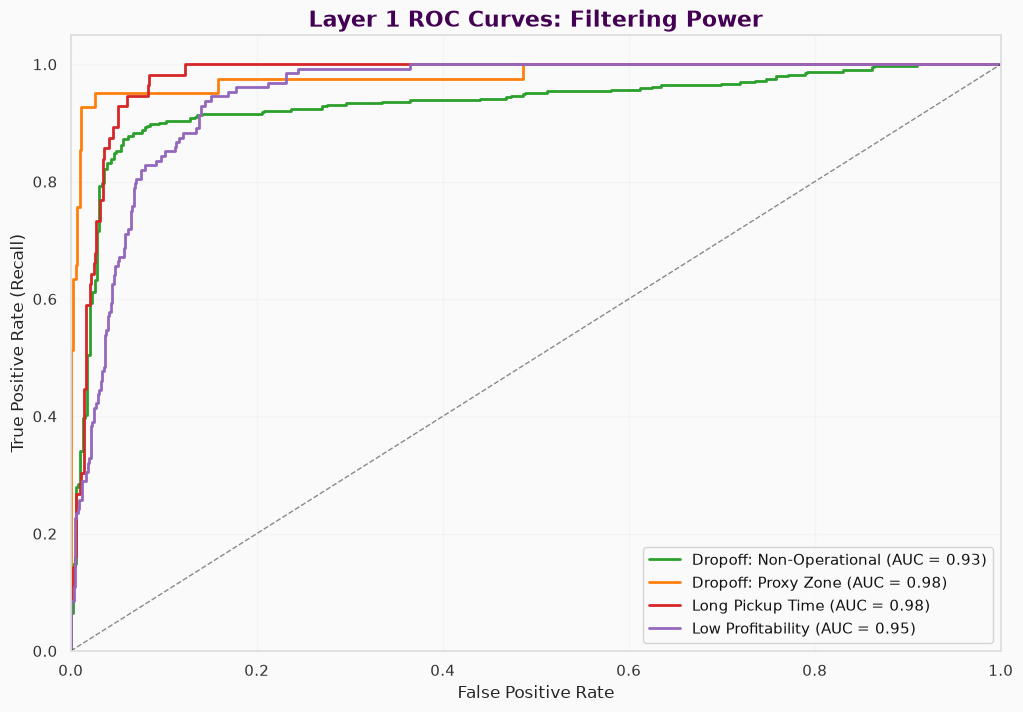

TOTAL MACRO AUC-ROC: 0.9415


In [96]:
print("Calculating ROC-AUC Curves for Layer 1...")

model = model_champion_L1
X_true = X_L1_test
y_true = y_L1_test

classes = model.classes_
class_names = list(le_L1.classes_)
n_classes = len(classes)

y_bin = label_binarize(y_true, classes=classes)

y_score = model.predict_proba(X_true)

plt.figure(figsize=(12, 8))
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    linewidth = 4 if "NUANCED" in class_names[i] else 2

    plt.plot(fpr, tpr, color=color, lw=linewidth,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Layer 1 ROC Curves: Filtering Power', fontsize=16, fontweight='bold', color=PIENZA_PURPLE)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.2)
plt.show()

try:
    auc_macro = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
    print(f"TOTAL MACRO AUC-ROC: {auc_macro:.4f}")
except Exception as e:
    print(f"AUC-ROC Macro could not be computed: {e}")

#### 2.14 — PR-AUC curves

One-vs-rest precision-recall curves for all Layer 1 classes.

Calculating Precision-Recall Curves (PR-AUC) for Layer 1...


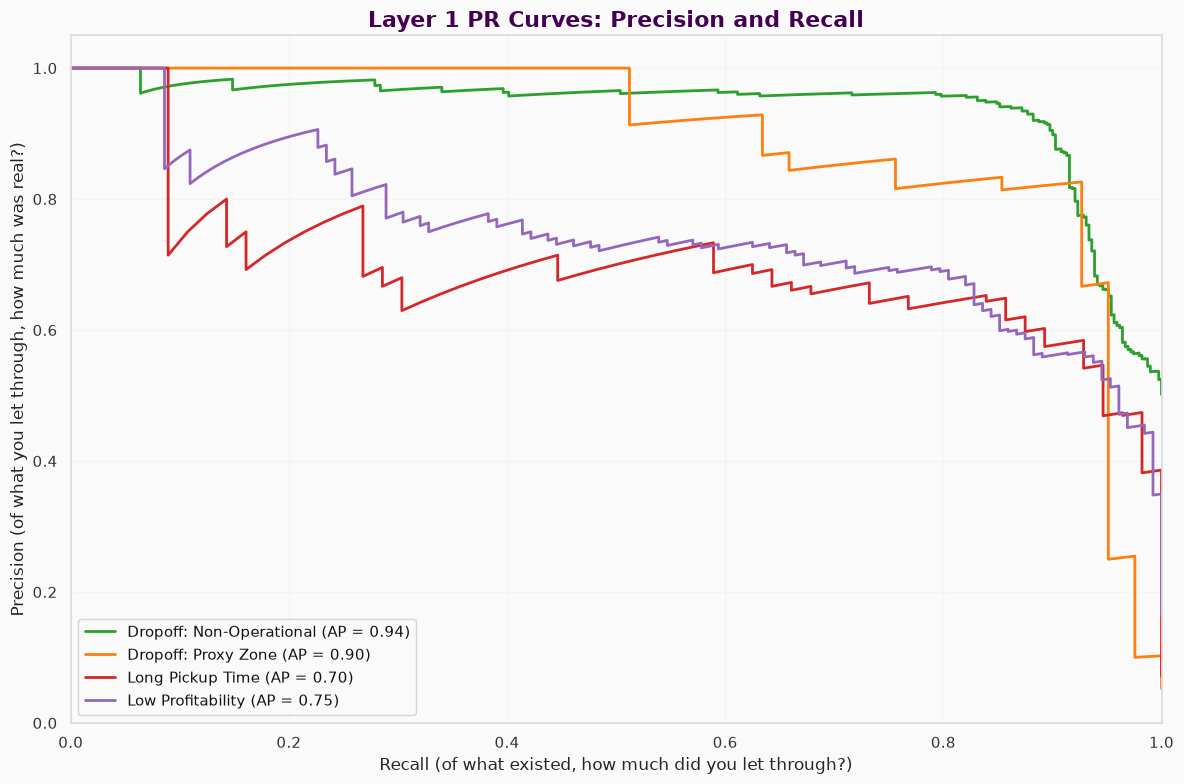


PRECISION REPORT (PR-AUC)
TOTAL AVERAGE PRECISION MACRO: 0.8209
PR-AUC Macro could not be computed: list index out of range


In [97]:
print("Calculating Precision-Recall Curves (PR-AUC) for Layer 1...")

model = model_champion_L1
X_true = X_L1_test
y_true = y_L1_test

classes = model.classes_
class_names = list(le_L1.classes_)
n_classes = len(classes)

y_bin = label_binarize(y_true, classes=classes)
y_score = model.predict_proba(X_true)

plt.figure(figsize=(12, 8))
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

ap_scores = [] # Store the Average Precision for each class

for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
    ap_scores.append(avg_precision)

    linewidth = 4 if "NUANCED" in class_names[i] else 2

    plt.plot(recall, precision, color=color, lw=linewidth,
             label=f'{class_names[i]} (AP = {avg_precision:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (of what existed, how much did you let through?)', fontsize=12)
plt.ylabel('Precision (of what you let through, how much was real?)', fontsize=12)
plt.title('Layer 1 PR Curves: Precision and Recall', fontsize=16, fontweight='bold', color="#440154")

plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("PRECISION REPORT (PR-AUC)")
print("="*60)
try:
    ap_macro = np.mean(ap_scores)
    print(f"TOTAL AVERAGE PRECISION MACRO: {ap_macro:.4f}")

    nuanced_idx = np.where(np.array(class_names) == "THE_NUANCED_REST")[0][0]
    print(f"THE_NUANCED_REST Average Precision: {ap_scores[nuanced_idx]:.4f}")

    baseline = np.sum(y_bin[:, nuanced_idx]) / len(y_true)
    print(f"Baseline (chance) for THE_NUANCED_REST: {baseline:.1%} (baseline cleared)")
except Exception as e:
    print(f"PR-AUC Macro could not be computed: {e}")
print("="*60)

<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

*Layer 1 is complete: 0.81 F1-Macro, 0.95 AUC, purging 74.4% of operational noise while retaining 87.3% recall on `THE_NUANCED_REST`. The purified 25.6% now passes to Layer 2, the Nuance Engine.*

</div>

## Phase 3 — Layer 2 (Nuance Classifier)

Trains and validates the second-stage classifier that resolves the nuanced cases Layer 1 passed through (Accepted vs. Expected Value Gamble vs. Strategic Mismatch), plus a lightweight 6-feature variant for comparison.

#### 3.1 — Layer 2 data isolation

Isolates the nuanced universe (Accepted, Expected Value Gamble, Strategic Mismatch) from the master dataset.

In [98]:
print("Forging Layer 2: Nuanced Universe...")

# IDs: 9999 (Accept), 6 (EEUM), 5 (DSM) -> ID 2 (Proxy) removed
nuanced_ids = [9999, 6, 5]

strat_mask = df_input['reason_primary_fk'].fillna(9999).isin(nuanced_ids)

# Note: inherits df_input, which already has the Class 7 filter applied.
df_L2 = df_input[strat_mask].copy()

print(f"Nuanced Universe Isolated. Total samples for Layer 2: {len(df_L2)}")

def map_layer2_target(val):
    if val == 9999: return "ACCEPTED"
    if val == 6: return "Expected Value Gamble"
    if val == 5: return "Strategic Mismatch"
    # Proxy no longer exists here
    return "Unknown"

df_L2['target_text'] = df_L2['reason_primary_fk'].fillna(9999).apply(map_layer2_target)

le_L2 = LabelEncoder()
y_L2 = le_L2.fit_transform(df_L2['target_text'])

print(f"Layer 2 Target Ready. Classes: {list(le_L2.classes_)}")

print("\nNATURAL BALANCE IN LAYER 2:")
print(df_L2['target_text'].value_counts(normalize=True))

print("\n--- LAYER 2 DATASET IS READY. PROCEED TO FEATURE SELECTION ---")

Forging Layer 2: Nuanced Universe...
Nuanced Universe Isolated. Total samples for Layer 2: 951
Layer 2 Target Ready. Classes: ['ACCEPTED', 'Expected Value Gamble', 'Strategic Mismatch']

NATURAL BALANCE IN LAYER 2:
target_text
ACCEPTED                 0.363828
Expected Value Gamble    0.347003
Strategic Mismatch       0.289169
Name: proportion, dtype: float64

--- LAYER 2 DATASET IS READY. PROCEED TO FEATURE SELECTION ---


#### 3.2 — Layer 2 feature foundry

Builds the Layer 2 feature matrix from the 19 Focused features plus 4 categorical winners, with zero category fusion.

In [99]:
print("Forging Layer 2 Feature Matrix (The Pure Nuance Engine)...")

focused_L2 = [
    'upfront_fare', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'eph_complete_index_ML',
    'home_vector_alignment_score', 'traffic_volatility_index_ml'
]

categorical_L2 = [
    'final_zone_id',
    'hour_of_day',
    'day_of_week',
    'product_category_fk'
]

# Shared with the Week 6 rebuild and false-positive cells
def build_l2_raw_features(df):
    """Numeric + categorical feature engineering for Layer 2, pre-scaling."""
    X_num = df[focused_L2].copy()
    for col in ['traffic_volatility_index_ml']:
        if col in X_num.columns:
            X_num[col] = pd.to_numeric(X_num[col], errors='coerce')
    X_num = X_num.fillna(0)

    skewed_vars = [
        'upfront_fare', 'est_trip_time_sec',
        'traffic_index_base_120', 'total_accumulated_deadhead_sec',
        'cycle_cumulative_net_earnings', 'traffic_volatility_index_ml'
    ]
    for col in skewed_vars:
        if col in X_num.columns:
            X_num[f'log_{col}'] = np.log1p(X_num[col].clip(lower=0))
            X_num = X_num.drop(columns=[col])

    X_cat = df[categorical_L2].copy().fillna("N/A").astype(str)
    X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

    X_raw = pd.concat([X_num, X_cat_encoded], axis=1)
    regex = re.compile(r"\[|\]|<", re.IGNORECASE)
    X_raw.columns = [
        regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col
        for col in X_raw.columns
    ]
    return X_raw

X_L2_raw = build_l2_raw_features(df_L2)

scaler_L2 = StandardScaler()
X_L2 = pd.DataFrame(
    scaler_L2.fit_transform(X_L2_raw),
    columns=X_L2_raw.columns,
    index=df_L2.index
)

print(f"Layer 2 Feature Matrix Purified & Fixed. Shape: {X_L2.shape}")

Forging Layer 2 Feature Matrix (The Pure Nuance Engine)...
Layer 2 Feature Matrix Purified & Fixed. Shape: (951, 93)


#### 3.3 — Layer 2 model comparison

Cross-validates GaussianNB, LogReg, and XGBoost on the nuanced universe.

In [100]:
print("Initiating Layer 2 model comparison...")
print(f"-> Dataset Size: {X_L2.shape[0]} samples | {X_L2.shape[1]} features.")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}

contenders = {
    "GaussianNB": GaussianNB(),

    "LogReg Balanced": LogisticRegression(
        class_weight='balanced', solver='lbfgs', max_iter=5000, random_state=42
    ),

    "Apex (XGBoost Default)": XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        objective='multi:softprob', n_jobs=-1, random_state=42
    )
}

l2_results = {}

for name, model in contenders.items():
    print(f"Testing {name}...")

    cv_results = cross_validate(model, X_L2, y_L2, cv=skf, scoring=scoring, n_jobs=-1)

    l2_results[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'Accuracy (Mean)': cv_results['test_accuracy'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std()
    }

df_l2_leaderboard = pd.DataFrame(l2_results).T.sort_values(by='F1_Macro (Mean)', ascending=False)

print("\n" + "="*70)
print("LAYER 2 LEADERBOARD")
print("="*70)
display(df_l2_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

print("\nInsight:")
print(f"-> If F1-Macro clears 0.60, the nuance problem is solved.")
print(f"-> Look at the gap between LogReg and XGBoost: this is where non-linearity pays off.")

Initiating Layer 2 model comparison...
-> Dataset Size: 951 samples | 93 features.
Testing GaussianNB...
Testing LogReg Balanced...


Testing Apex (XGBoost Default)...

LAYER 2 LEADERBOARD


,F1_Macro (Mean),Accuracy (Mean),Stability (Std Dev)
Apex (XGBoost Default),0.699564,0.698214,0.025269
LogReg Balanced,0.623765,0.625643,0.010814
GaussianNB,0.359251,0.448928,0.042505



Insight:
-> If F1-Macro clears 0.60, the nuance problem is solved.
-> Look at the gap between LogReg and XGBoost: this is where non-linearity pays off.


#### 3.4 — Layer 2 tuning

Randomized hyperparameter search for the Layer 2 model, cached to disk.

In [101]:
_CACHE_PATH_L2 = os.path.join(DUMP_DIR, "0509X_l2_strategist_champion.joblib")

if os.path.exists(_CACHE_PATH_L2) and not FORCE_UPDATE:
    print(f"Cache found — loading Layer 2 champion from {_CACHE_PATH_L2}")
    search_L2 = joblib.load(_CACHE_PATH_L2)
    model_champion_L2 = search_L2.best_estimator_
    print(f"Best F1-Macro (Nuance): {search_L2.best_score_:.4f}")
else:
    print("PHASE 2: Initiating Optimal Tuning for the Nuance Engine...")

    param_dist_L2 = {
        'n_estimators': randint(100, 400),
        'max_depth': [3, 4, 5, 6],
        'learning_rate': uniform(0.01, 0.1),
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 5),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 10),
        'reg_lambda': uniform(1, 10)
    }

    xgb_l2 = xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )

    skf_l2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    search_L2 = RandomizedSearchCV(
        estimator=xgb_l2,
        param_distributions=param_dist_L2,
        n_iter=30,
        scoring='f1_macro',
        cv=skf_l2,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    start_time = time.time()
    print(f"Tuning Layer 2 on {X_L2.shape} matrix...")
    search_L2.fit(X_L2, y_L2)
    elapsed = time.time() - start_time

    model_champion_L2 = search_L2.best_estimator_

    joblib.dump(search_L2, _CACHE_PATH_L2)
    print(f"\n LAYER 2 TUNING COMPLETE in {elapsed:.1f}s — cached to {_CACHE_PATH_L2}")
    print(f"Best F1-Macro (Nuance): {search_L2.best_score_:.4f}")
    print(f"Winning Params: {search_L2.best_params_}")

Cache found — loading Layer 2 champion from /workspaces/pienza/data/dumped_files/0509X_l2_strategist_champion.joblib
Best F1-Macro (Nuance): 0.7185


#### 3.5 — Temporal split (Week 6 holdout)

Synchronizes the nuanced universe with the Week 6 holdout split.

In [102]:
print("Synchronizing Layer 2 Temporal Split (Week 6 Holdout)...")

# (df_L2 is already a subset, so we just apply the Week 6 rule)
test_mask_l2 = (df_L2['week_id'] == 6)
train_mask_l2 = (df_L2['week_id'] < 6)

X_train_l2 = X_L2[train_mask_l2]
X_test_l2 = X_L2[test_mask_l2]

y_train_l2 = y_L2[train_mask_l2]
y_test_l2 = y_L2[test_mask_l2]

print(f"Split Complete:")
print(f"-> Universe L2 Training (W1-5): {len(X_train_l2)} samples.")
print(f"-> Universe L2 Holdout (W6): {len(X_test_l2)} samples.")

if len(X_test_l2) == 0:
    print("CRITICAL: No Week 6 data in the Nuanced universe. Check the Master Coalesce step.")

Synchronizing Layer 2 Temporal Split (Week 6 Holdout)...
Split Complete:
-> Universe L2 Training (W1-5): 787 samples.
-> Universe L2 Holdout (W6): 164 samples.


#### 3.6 — Layer 2 final evaluation

Reports Layer 2's classification performance and plots the confusion matrix heatmap.

Executing Layer 2 final evaluation...

LAYER 2: CLASSIFICATION REPORT
                       precision    recall  f1-score   support

             ACCEPTED       0.91      0.91      0.91        67
Expected Value Gamble       0.84      0.88      0.86        41
   Strategic Mismatch       0.96      0.93      0.95        56

             accuracy                           0.91       164
            macro avg       0.90      0.91      0.90       164
         weighted avg       0.91      0.91      0.91       164



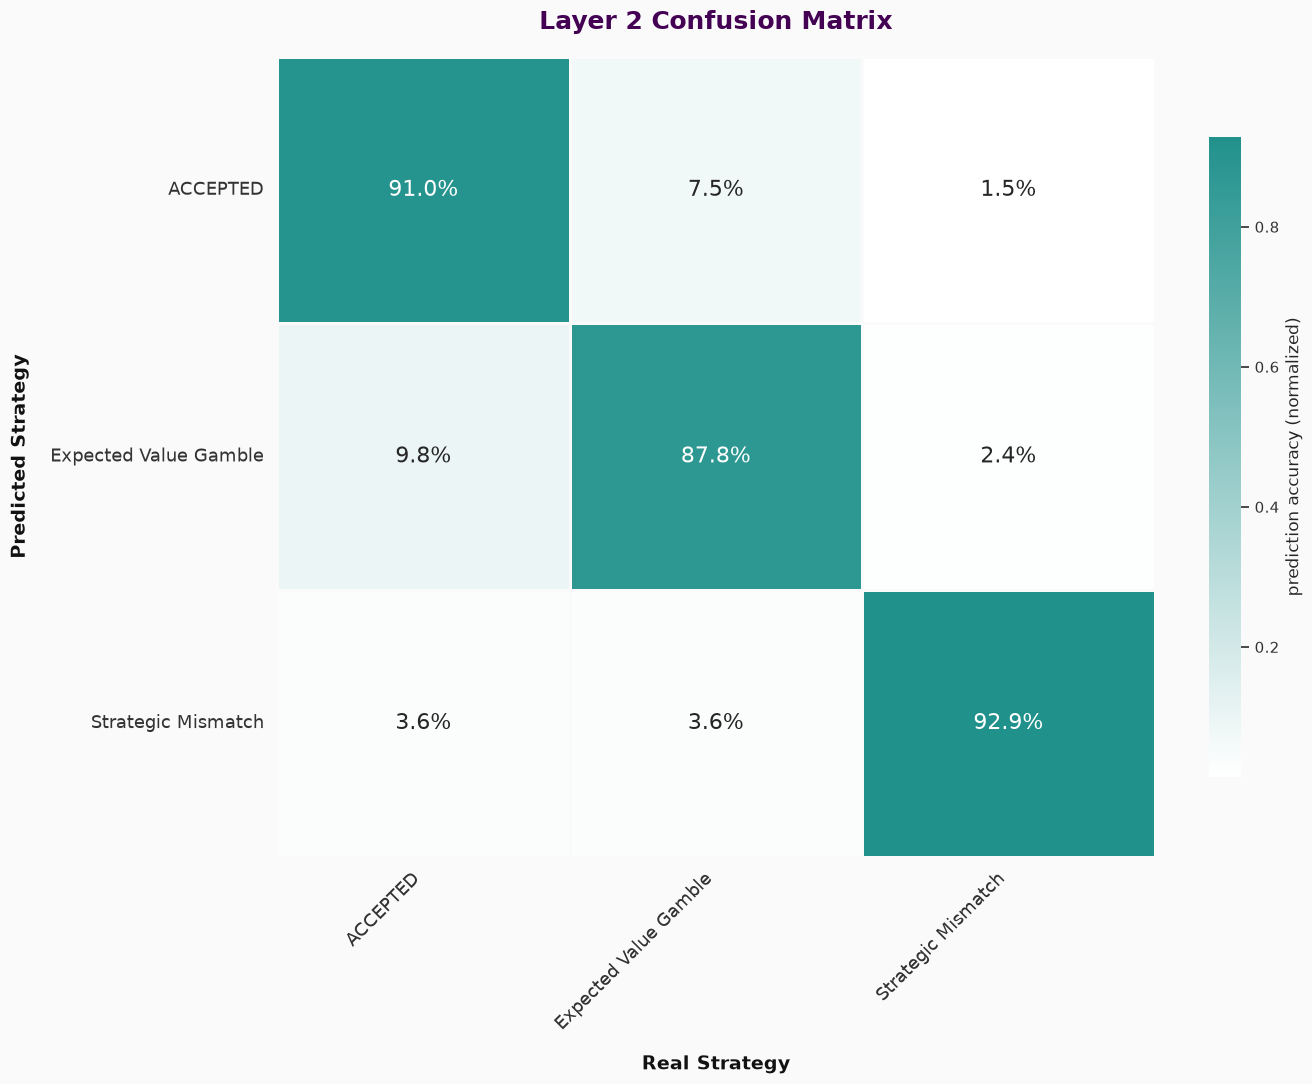

In [103]:

print("Executing Layer 2 final evaluation...")

y_pred_l2 = model_champion_L2.predict(X_test_l2)
class_names_l2 = list(le_L2.classes_)

print("\n" + "="*80)
print("LAYER 2: CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test_l2, y_pred_l2, target_names=class_names_l2, zero_division=0))

cm = confusion_matrix(y_test_l2, y_pred_l2, normalize='true')

fig, ax = plt.subplots(figsize=(14, 11), facecolor=PIENZA_GREY)
ax.set_facecolor(PIENZA_GREY)

sns.heatmap(
    cm,
    annot=True,
    fmt=".1%",
    cmap=cmap_pienza,
    xticklabels=class_names_l2,
    yticklabels=class_names_l2,
    cbar_kws={'shrink': 0.8, 'label': 'prediction accuracy (normalized)'},
    linewidths=2,
    linecolor=PIENZA_GREY,
    ax=ax,
    annot_kws={"size": 16}
)

ax.set_title("Layer 2 Confusion Matrix",
             fontsize=18, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("Real Strategy", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
ax.set_ylabel("Predicted Strategy", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(rotation=0, fontsize=13)

plt.tight_layout()
plt.show()

#### 3.7 — ROC-AUC curves

One-vs-rest ROC curves for all Layer 2 classes.

Calculating ROC-AUC Curves for Layer 2...


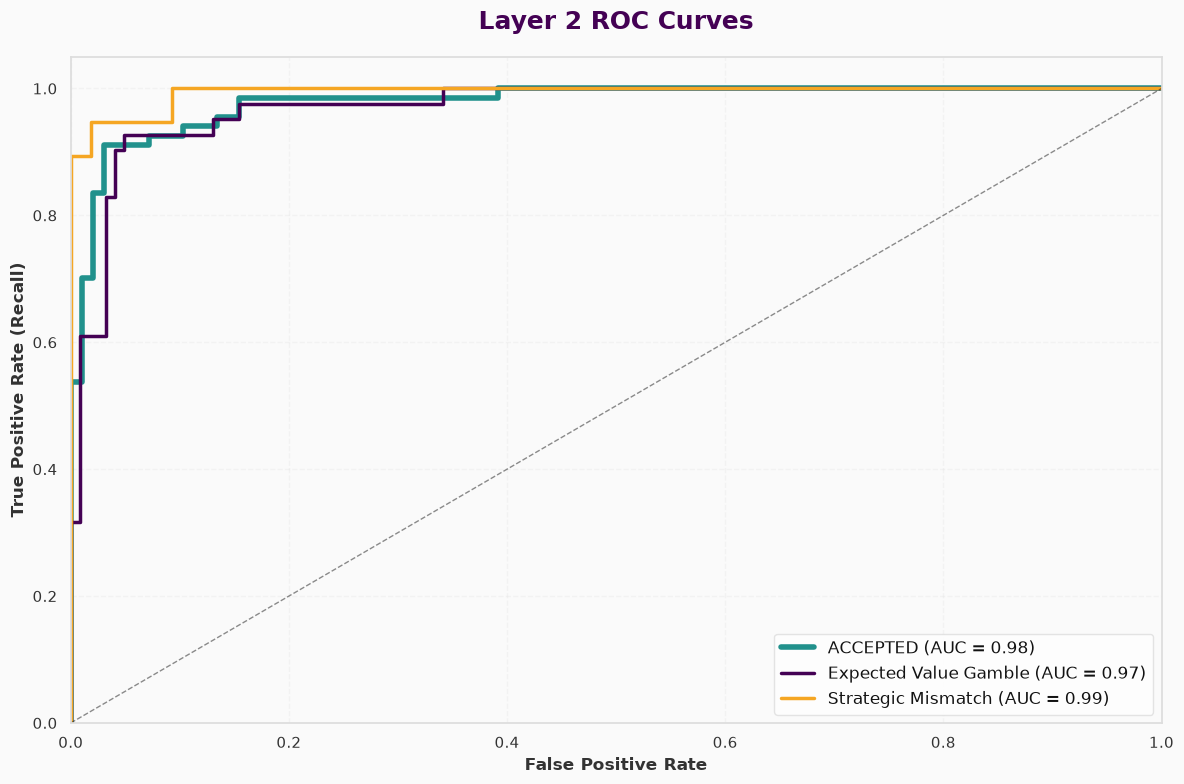


DISCRIMINATION REPORT (ROC-AUC)
TOTAL MACRO ROC-AUC: 0.9811


In [104]:
print("Calculating ROC-AUC Curves for Layer 2...")

model = model_champion_L2
X_true = X_test_l2
y_true = y_test_l2

classes = model.classes_
class_names = list(le_L2.classes_)
n_classes = len(classes)

y_bin = label_binarize(y_true, classes=classes)
y_score = model.predict_proba(X_true)

colors = ['#21918c', '#440154', '#f5a623'] # Teal, Purple, Orange

plt.figure(figsize=(12, 8))
plt.gcf().patch.set_facecolor('#FAFAFA')
plt.gca().set_facecolor('#FAFAFA')

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    linewidth = 4 if "ACCEPTED" in class_names[i].upper() else 2.5

    plt.plot(fpr, tpr, color=color, lw=linewidth,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold', color="#333333")
plt.ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold', color="#333333")
plt.title('Layer 2 ROC Curves', fontsize=18, fontweight='bold', color="#440154", pad=20)

plt.legend(loc="lower right", fontsize=12, frameon=True, facecolor='white', edgecolor='#DDDDDD')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DISCRIMINATION REPORT (ROC-AUC)")
print("="*60)
try:
    auc_macro = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
    print(f"TOTAL MACRO ROC-AUC: {auc_macro:.4f}")
except Exception as e:
    print(f"ROC-AUC Macro could not be computed: {e}")
print("="*60)

#### 3.8 — PR-AUC curves

One-vs-rest precision-recall curves for all Layer 2 classes, with baseline uplift.

Calculating Precision-Recall Curves (PR-AUC) for Layer 2...


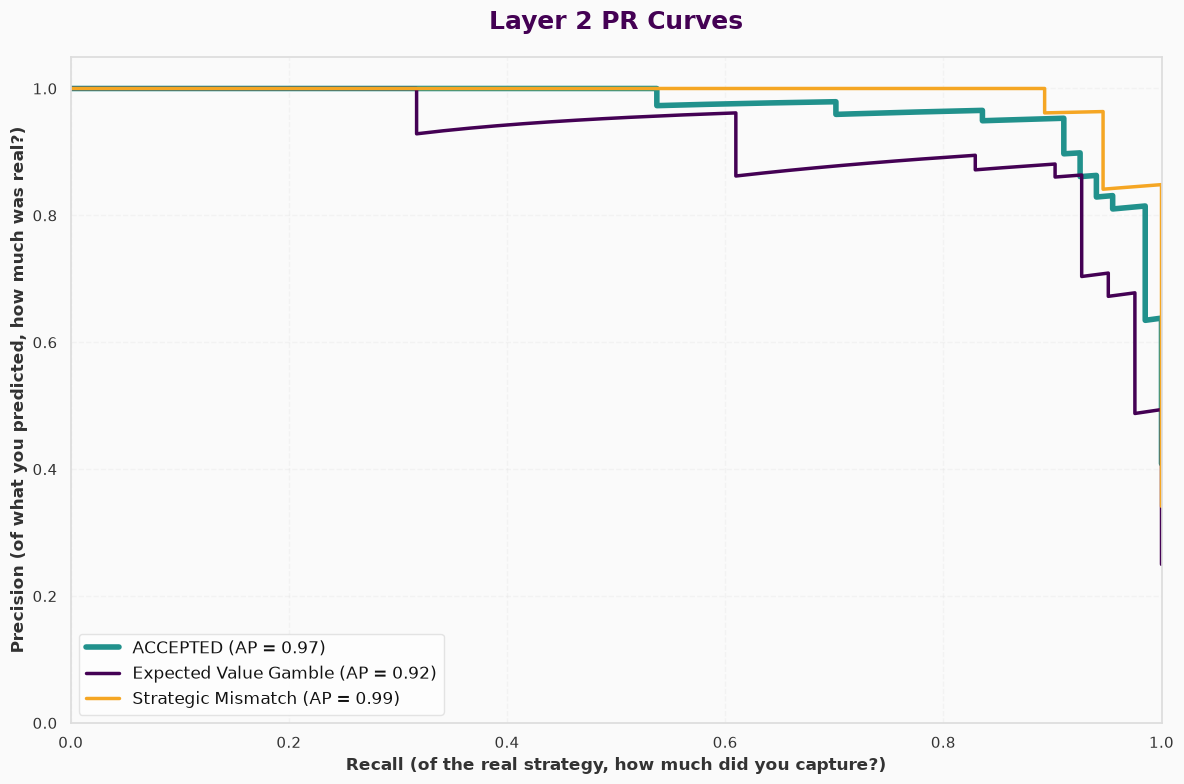


PRECISION REPORT (PR-AUC LAYER 2)
AVERAGE PRECISION MACRO (Total): 0.9600

BASELINES (chance) vs PERFORMANCE (AP):
* ACCEPTED                      
-> Baseline (chance):  40.9%
-> Model AP:  97.1% (Uplift: +56.2 pts)
--------------------------------------------------
- Expected Value Gamble         
-> Baseline (chance):  25.0%
-> Model AP:  92.0% (Uplift: +67.0 pts)
--------------------------------------------------
- Strategic Mismatch            
-> Baseline (chance):  34.1%
-> Model AP:  99.0% (Uplift: +64.8 pts)
--------------------------------------------------


In [105]:
print("Calculating Precision-Recall Curves (PR-AUC) for Layer 2...")

model = model_champion_L2
X_true = X_test_l2
y_true = y_test_l2

classes = model.classes_
class_names = list(le_L2.classes_)
n_classes = len(classes)

y_bin = label_binarize(y_true, classes=classes)
y_score = model.predict_proba(X_true)

colors = ['#21918c', '#440154', '#f5a623'] # Teal, Purple, Orange

plt.figure(figsize=(12, 8))
plt.gcf().patch.set_facecolor('#FAFAFA')
plt.gca().set_facecolor('#FAFAFA')

ap_scores = [] # Store the AP for each class

for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
    ap_scores.append(avg_precision)

    linewidth = 4 if "ACCEPTED" in class_names[i].upper() else 2.5

    plt.plot(recall, precision, color=color, lw=linewidth,
             label=f'{class_names[i]} (AP = {avg_precision:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (of the real strategy, how much did you capture?)', fontsize=12, fontweight='bold', color="#333333")
plt.ylabel('Precision (of what you predicted, how much was real?)', fontsize=12, fontweight='bold', color="#333333")
plt.title('Layer 2 PR Curves', fontsize=18, fontweight='bold', color="#440154", pad=20)

plt.legend(loc="lower left", fontsize=12, frameon=True, facecolor='white', edgecolor='#DDDDDD')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PRECISION REPORT (PR-AUC LAYER 2)")
print("="*70)
try:
    ap_macro = np.mean(ap_scores)
    print(f"AVERAGE PRECISION MACRO (Total): {ap_macro:.4f}\n")

    print("BASELINES (chance) vs PERFORMANCE (AP):")
    for i, class_name in enumerate(class_names):
        # The PR baseline is the real proportion of that class in Layer 2
        baseline = np.sum(y_bin[:, i]) / len(y_true)
        ap = ap_scores[i]
        uplift = ap - baseline

        marker = "*" if "ACCEPTED" in class_name.upper() else "-"

        print(f"{marker} {class_name:<30}")
        print(f"-> Baseline (chance): {baseline:>6.1%}")
        print(f"-> Model AP: {ap:>6.1%} (Uplift: +{uplift*100:.1f} pts)")
        print("-" * 50)

except Exception as e:
    print(f"PR-AUC report failed: {e}")

#### 3.9 — Learning curve diagnostic

Learning curve for the Layer 2 model.

Generating the RAW Learning Curve for Layer 2...


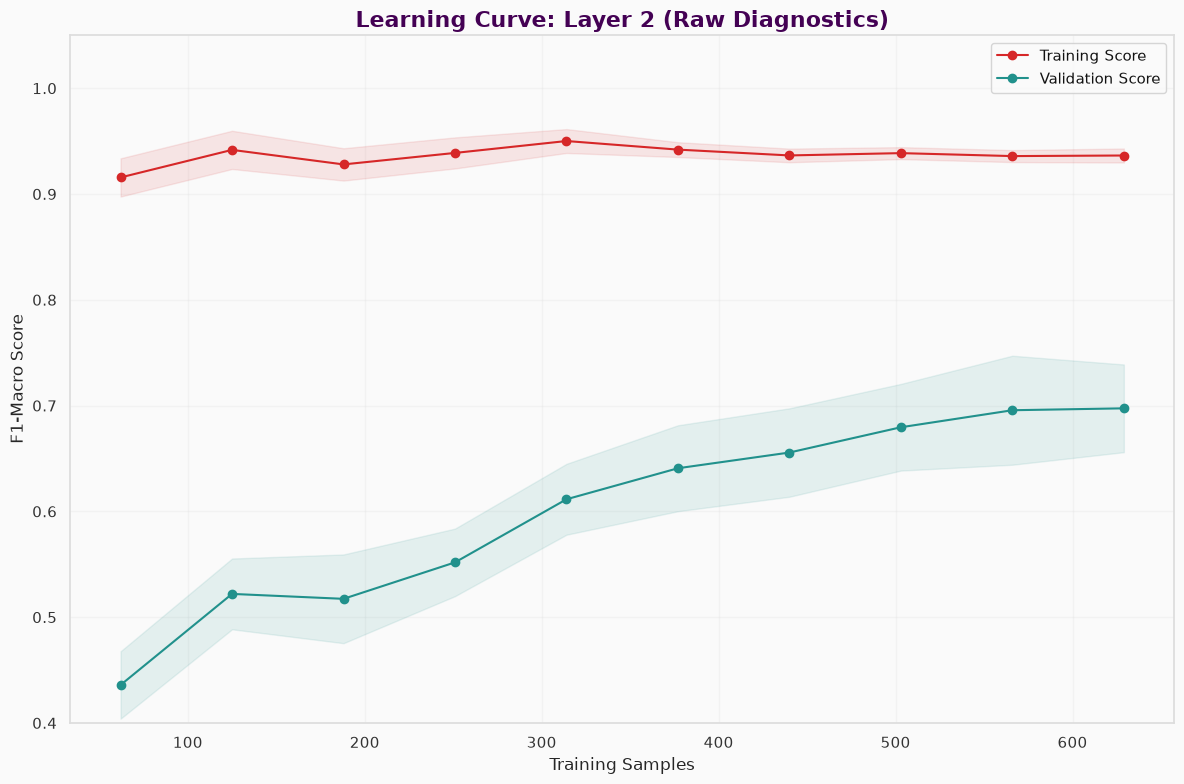


FINAL DIAGNOSIS:
-> Final Train Score: 0.9364
-> Final Validation Score: 0.6974
-> Gap (Overfitting): 0.2390


In [106]:
print("Generating the RAW Learning Curve for Layer 2...")

X_curve_l2 = X_train_l2.copy()
y_curve_l2 = y_train_l2

# XGBoost rejects certain characters ([, ], <) in column names
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_curve_l2.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_curve_l2.columns]

cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes_cfg = np.linspace(0.1, 1.0, 10)

train_sizes, train_scores, test_scores = learning_curve(
    model_champion_L2,
    X_curve_l2,
    y_curve_l2,
    cv=cv_lc,
    scoring='f1_macro',
    n_jobs=-1,
    train_sizes=train_sizes_cfg,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 8))

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#21918c")

plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training Score")
plt.plot(train_sizes, test_mean, 'o-', color="#21918c", label="Validation Score")

plt.title("Learning Curve: Layer 2 (Raw Diagnostics)", fontsize=16, fontweight='bold', color="#440154")
plt.xlabel("Training Samples")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - test_mean[-1]
print("\n" + "="*50)
print(f"FINAL DIAGNOSIS:")
print("="*50)
print(f"-> Final Train Score: {train_mean[-1]:.4f}")
print(f"-> Final Validation Score: {test_mean[-1]:.4f}")
print(f"-> Gap (Overfitting): {gap:.4f}")
print("="*50)

#### 3.10 — Lightweight Layer 2 variant

Trains a regularized 6-feature XGBoost model as a lightweight alternative to the full Layer 2 model.

Forging the lightweight Layer 2 variant (Top 6 Variables)...
Evaluating the learning curve (Raw)...


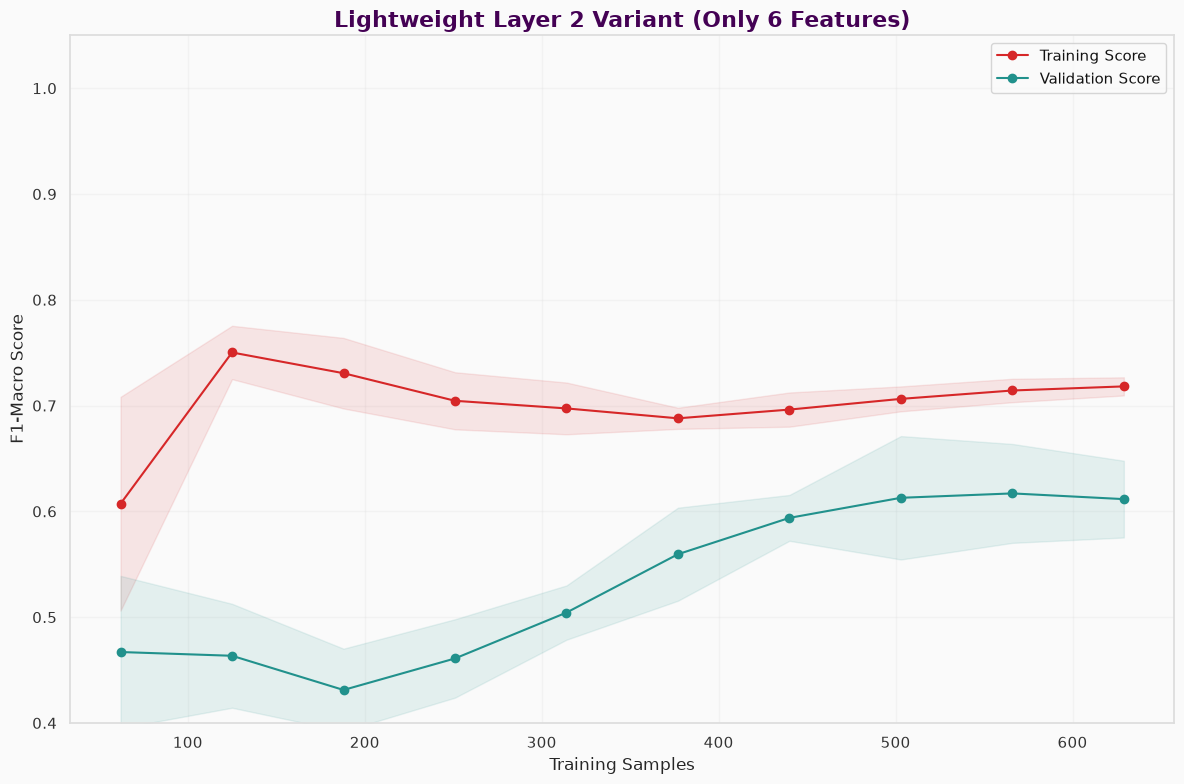

LIGHTWEIGHT MODEL DIAGNOSIS:
-> Final Train Score: 0.7182
-> Final Validation Score: 0.6116
-> New Gap: 0.1066


In [107]:
print("Forging the lightweight Layer 2 variant (Top 6 Variables)...")

spartan_features = [
    'session_progress_ratio', # the fatigue clock
    'total_accumulated_deadhead_sec', # desperation
    'cycle_rolling_avg_spread', # market expectation
    'eph_operational_index', # pure profitability (replaces upfront_fare)
    'cycle_cumulative_net_earnings', # the day's target
    'home_vector_alignment_score' # the pull toward home
]

def build_lightweight_raw_features(df):
    """Numeric feature engineering for the lightweight Layer 2 variant, pre-scaling."""
    X_num = df[spartan_features].copy()
    for col in ['total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings']:
        if col in X_num.columns:
            X_num[f'log_{col}'] = np.log1p(X_num[col].clip(lower=0))
            X_num = X_num.drop(columns=[col])
    return X_num

X_spartan_num = build_lightweight_raw_features(df_L2)

scaler_spartan = StandardScaler()
X_spartan_scaled = pd.DataFrame(
    scaler_spartan.fit_transform(X_spartan_num),
    columns=X_spartan_num.columns,
    index=df_L2.index
)

train_mask_l2 = (df_L2['week_id'] < 6)
X_train_spartan = X_spartan_scaled[train_mask_l2]

xgb_spartan = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=3,
    min_child_weight=7,
    learning_rate=0.05,
    gamma=2,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

print("Evaluating the learning curve (Raw)...")
cv_spartan = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes_cfg = np.linspace(0.1, 1.0, 10)

train_sizes, train_scores, test_scores = learning_curve(
    xgb_spartan, X_train_spartan, y_train_l2, cv=cv_spartan,
    scoring='f1_macro', n_jobs=-1, train_sizes=train_sizes_cfg, random_state=42
)

t_mean, t_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
v_mean, v_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)

plt.figure(figsize=(12, 8))
plt.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.1, color="#d62728")
plt.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.1, color="#21918c")
plt.plot(train_sizes, t_mean, 'o-', color="#d62728", label="Training Score")
plt.plot(train_sizes, v_mean, 'o-', color="#21918c", label="Validation Score")

plt.title("Lightweight Layer 2 Variant (Only 6 Features)", fontsize=16, fontweight='bold', color="#440154")
plt.xlabel("Training Samples")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

print(f"LIGHTWEIGHT MODEL DIAGNOSIS:")
print(f"-> Final Train Score: {t_mean[-1]:.4f}")
print(f"-> Final Validation Score: {v_mean[-1]:.4f}")
print(f"-> New Gap: {t_mean[-1] - v_mean[-1]:.4f}")

#### 3.11 — Full strategic DNA atlas

SHAP analysis across all three Layer 2 classes, with full semantic feature labeling.

Forging the Full Strategic DNA Atlas (Layer 2 - All Variables)...


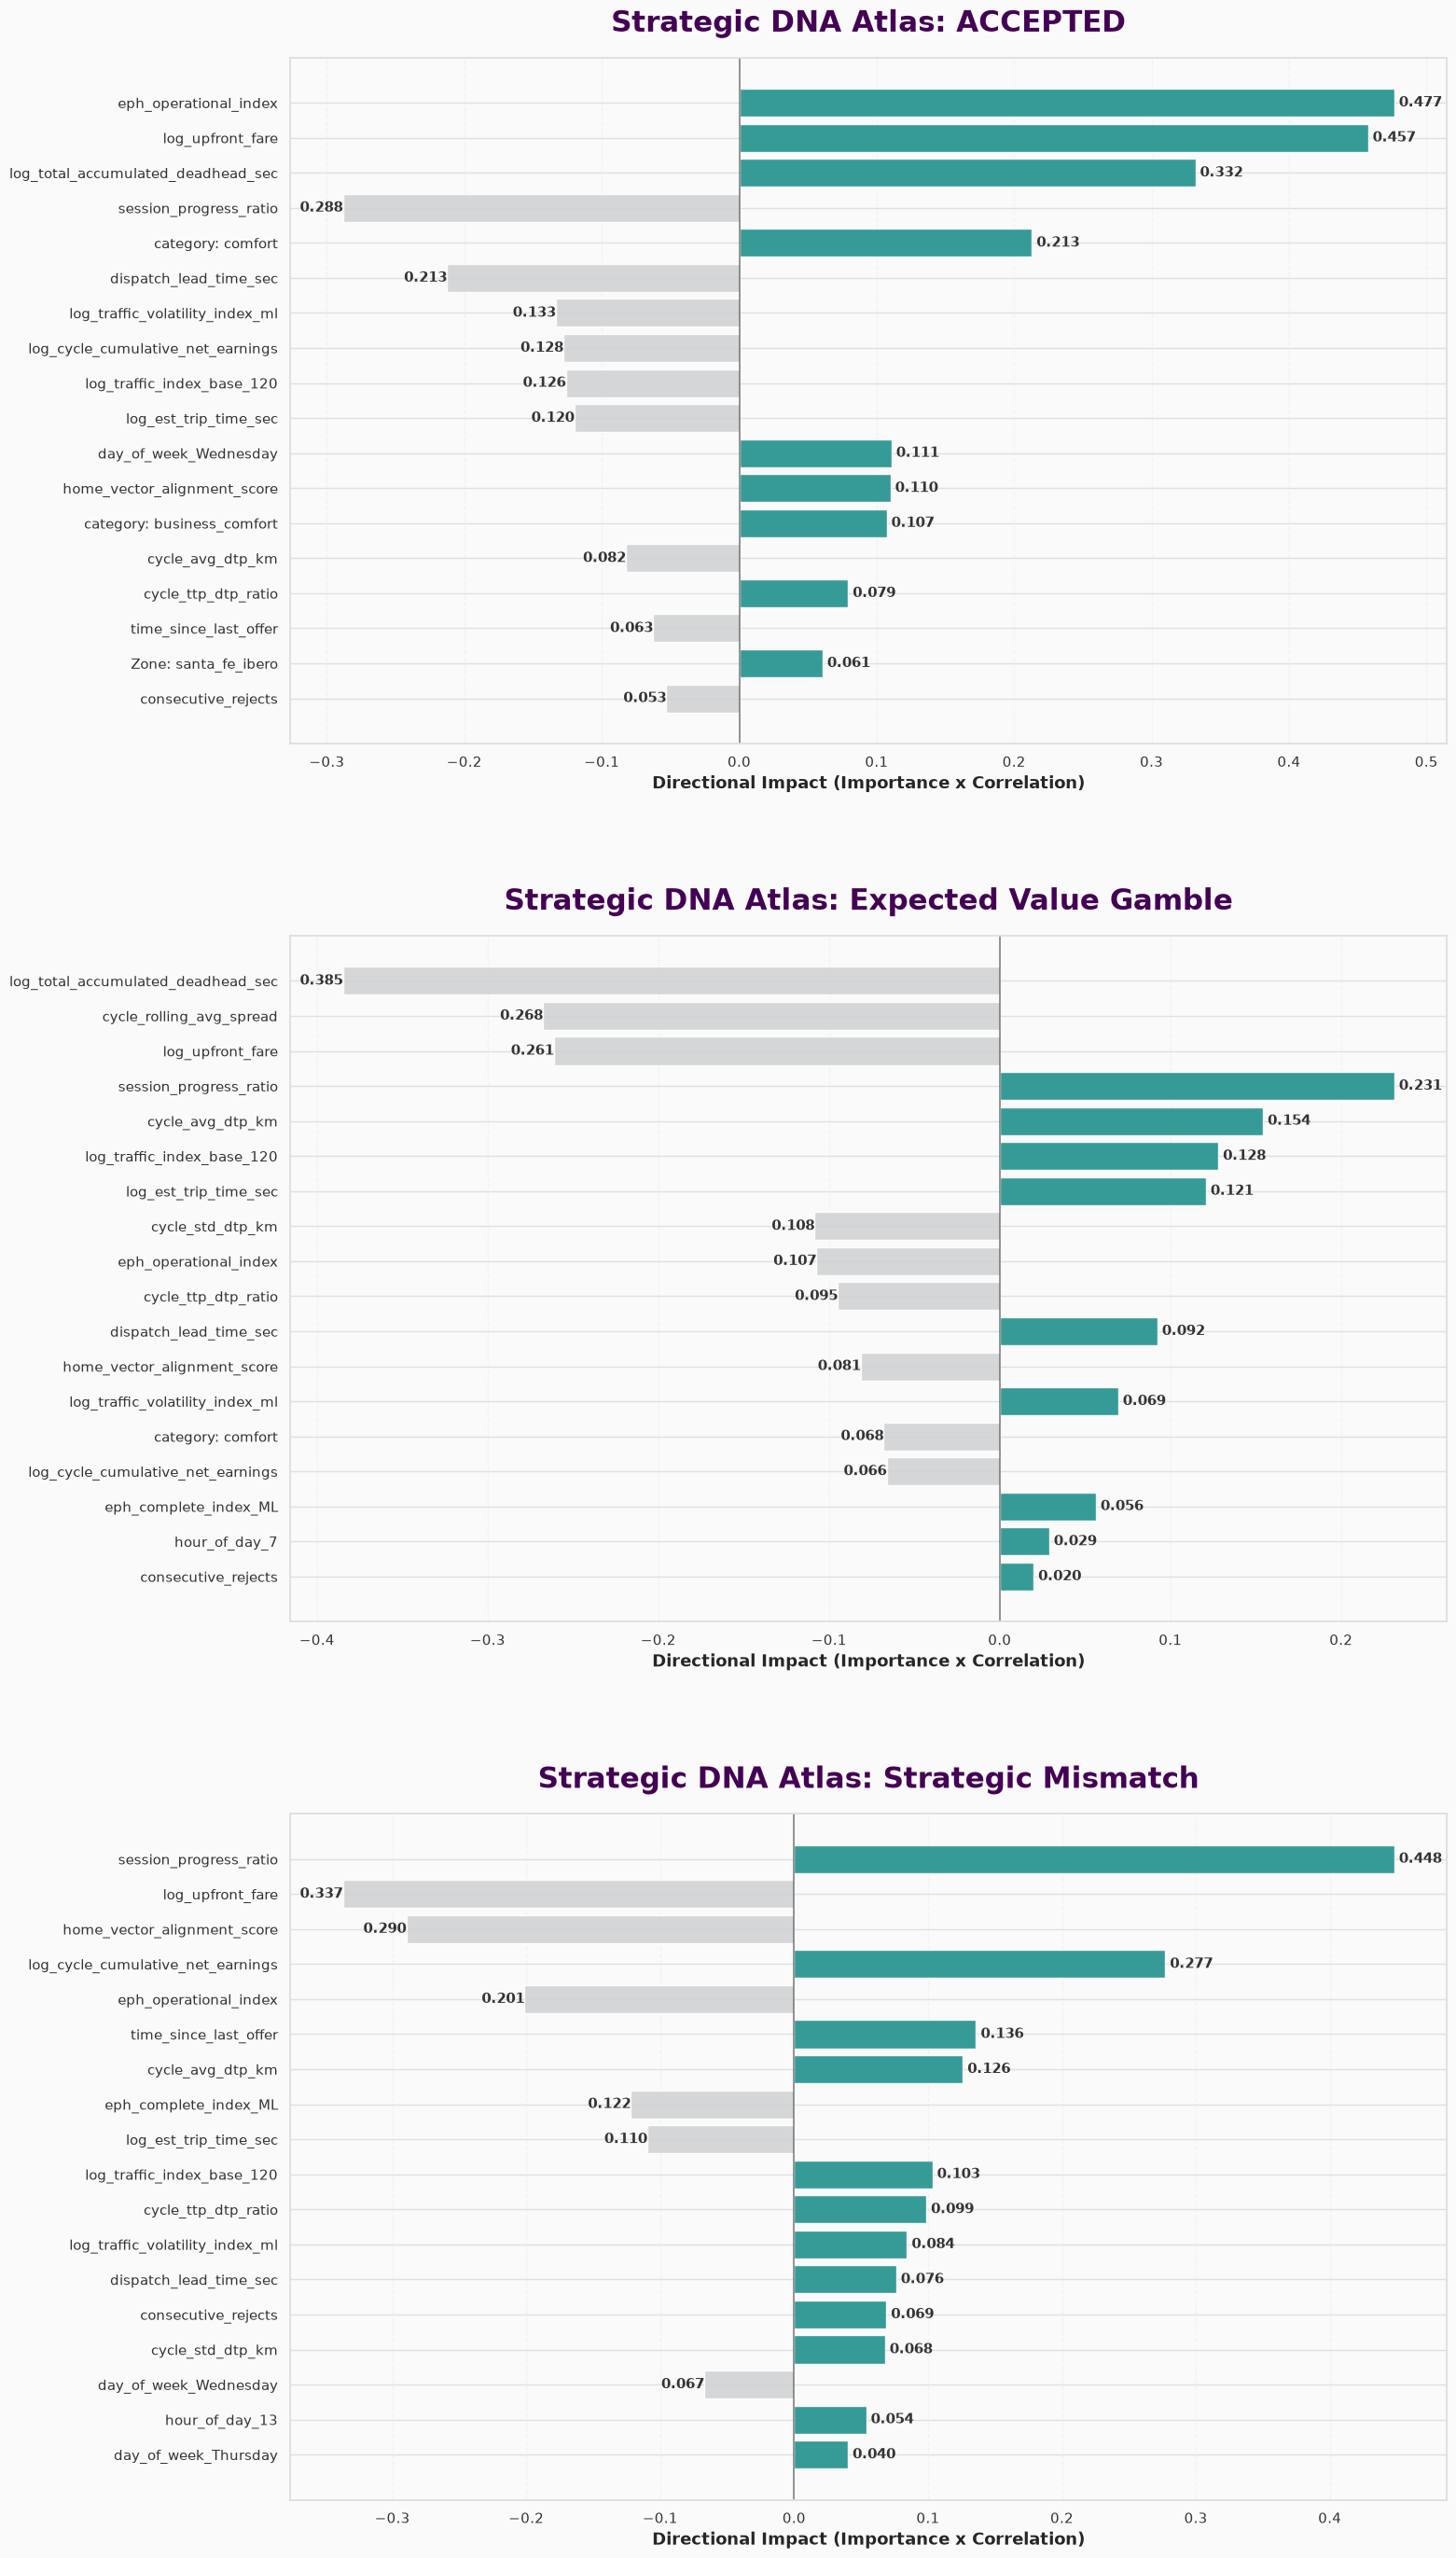

In [108]:
print("Forging the Full Strategic DNA Atlas (Layer 2 - All Variables)...")

p_map = globals().get('product_map', {})
z_metadata = df_input.drop_duplicates('final_zone_id').set_index('final_zone_id')['final_zone_name'].to_dict()

def map_full_semantic(feature_name):
    """Universal mapping of technical column names to human labels."""
    s_feat = str(feature_name)
    if 'final_zone_id_' in s_feat:
        raw_id = s_feat.split('final_zone_id_')[-1]
        return f"Zone: {z_metadata.get(raw_id, raw_id)}"
    if 'heuristic_flag_context_' in s_feat:
        return f"Context: {s_feat.split('heuristic_flag_context_')[-1]}"
    if 'product_category_fk_' in s_feat:
        raw_id = s_feat.split('product_category_fk_')[-1]
        try:
            p_id = int(float(raw_id))
            if p_id in p_map: return f"category: {p_map[p_id]}"
        except: pass
        return f"category: {raw_id}"
    return feature_name

classes_l2 = list(le_L2.classes_)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 34), facecolor="#FAFAFA")
plt.subplots_adjust(hspace=0.28) # Generous spacing so the labels don't crowd each other

if 'shap_values_L2' not in locals():
    _orig_float = builtins.float
    def _vec_safe_float(x):
        if isinstance(x, str) and x.startswith('['):
            x = _re.search(r'[+-]?[\d.]+(?:E[+-]?\d+)?', x).group()
        return _orig_float(x)
    builtins.float = _vec_safe_float
    try:
        explainer_L2 = shap.TreeExplainer(model_champion_L2)
        shap_values_L2 = explainer_L2.shap_values(X_test_l2, check_additivity=False)
    finally:
        builtins.float = _orig_float

for i, class_name in enumerate(classes_l2):
    ax = axes[i]

    if isinstance(shap_values_L2, list):
        class_shap = shap_values_L2[i]
    else:
        class_shap = shap_values_L2[:, :, i]

    f_importance = np.mean(np.abs(class_shap), axis=0)

    # Robust correlation (fixing NaNs and 0-StdDev warnings)
    corrs = []
    for col_idx in range(X_test_l2.shape[1]):
        f_val = X_test_l2.iloc[:, col_idx]
        s_val = class_shap[:, col_idx]
        if np.std(f_val) == 0 or np.std(s_val) == 0:
            corrs.append(0)
        else:
            c = np.corrcoef(f_val, s_val)[0, 1]
            corrs.append(c if not np.isnan(c) else 0)

    df_temp = pd.DataFrame({
        'Feature': X_test_l2.columns,
        'Importance': f_importance,
        'Impact': f_importance * np.sign(corrs),
        'Abs_Impact': np.abs(f_importance * np.sign(corrs))
    })

    df_temp['Semantic'] = df_temp['Feature'].apply(map_full_semantic)

    df_viz = df_temp.sort_values(by='Abs_Impact', ascending=False).head(18)
    df_viz = df_viz.iloc[::-1]  # reverse for top-to-bottom horizontal plotting

    colors = ["#21918c" if x > 0 else "#D0D3D4" for x in df_viz['Impact']]
    bars = ax.barh(df_viz['Semantic'], df_viz['Impact'], color=colors, alpha=0.9, edgecolor='white')
    ax.axvline(0, color="#333333", linewidth=1.2, alpha=0.6)

    ax.set_title(f"Strategic DNA Atlas: {class_name}", fontsize=22, fontweight='bold', color="#440154", pad=20)
    ax.set_xlabel("Directional Impact (Importance x Correlation)", fontsize=13, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, f' {abs(width):.3f}',
                va='center', ha='left' if width > 0 else 'right',
                fontsize=11, fontweight='bold', color="#333333")


plt.show()


---

## Appendix — variable journey

```mermaid
flowchart TD
    df_input["df_input\n(v_ML_Supervised, rare class purged)"] --> zones["final_zone_id / final_zone_name\n(merged zone naming)"]
    df_input --> features["Wide + Focused raw universes\n(scaled, one-hot fused)"]
    zones --> features

    features --> XL1["X_L1, y_L1\n(le_L1 encodes target)"]
    XL1 --> modelL1["model_champion_L1\n(tuned XGBClassifier)"]
    modelL1 --> predL1["X_L1_test, y_pred_L1"]

    features --> XL2["X_L2, y_L2\n(Nuanced subset isolated from df_input, le_L2 encodes target)"]
    XL2 --> modelL2["model_champion_L2\n(tuned XGBClassifier)"]
    XL2 --> spartan["xgb_spartan\n(lightweight 6-feature variant)"]
    modelL2 --> testL2["X_test_l2"]
    testL2 --> shap["shap_values_L2\n(Full strategic DNA atlas, 3.11)"]

    classDef default stroke:#21918c,stroke-width:2px;
    linkStyle default stroke:#21918c,stroke-width:2px;
```

<div style="border-left: 4px solid #21918c; padding: 4px 20px; background: rgba(33,145,140,0.05); border-radius: 0 6px 6px 0;">

*Scoped to the core research (Phases 1-3, through the 3.11 SHAP atlas) — the Streamlit-inputs appendix that follows is dashboard plumbing, not part of the formal research phases.*

</div>

## Appendix — Streamlit inputs

The research narrative concludes at 3.11 with the full SHAP atlas. Everything below packages the trained models' outputs for the Streamlit Observatory (probability exports, the Week 6 economic simulation, and reverse-audit checks) — useful for the live dashboards, but not part of the core research argument.

#### A.1 — Generate Layer 2 probabilities

Generates predict_proba output for the Layer 2 test set.

In [109]:
y_pred_probs_l2 = model_champion_L2.predict_proba(X_test_l2)

class_names_l2 = list(le_L2.classes_)

#### A.2 — Reverse audit of Layer 1 predictions

Cross-tabulates human vs. Layer 1 predictions on the exact test set used for the heatmap.

In [110]:
# Use y_L1_test and y_pred_L1, the same ones that generated the heatmap
human_real_test = le_L1.inverse_transform(y_L1_test)
ia_pred_test = le_L1.inverse_transform(y_pred_L1)

df_soT = pd.DataFrame({
    'Human_Real': human_real_test,
    'AI_Pred': ia_pred_test
})

print("GROUND TRUTH (Synchronized with the Heatmap):")
crosstab_final = pd.crosstab(df_soT['Human_Real'], df_soT['AI_Pred'], margins=True)
display(crosstab_final.style.background_gradient(cmap='Greens'))

GROUND TRUTH (Synchronized with the Heatmap):


AI_Pred,Dropoff: Non-Operational,Dropoff: Proxy Zone,Long Pickup Time,Low Profitability,THE_NUANCED_REST,All
Human_Real,,,,,,
Dropoff: Non-Operational,318,3,25,27,18,391
Dropoff: Proxy Zone,1,35,1,2,2,41
Long Pickup Time,1,0,54,0,1,56
Low Profitability,3,0,4,95,26,128
THE_NUANCED_REST,10,5,23,13,113,164
All,333,43,107,137,160,780


#### A.3 — Refit lightweight model

Fits the lightweight model (only defined during its learning curve) and verifies the Layer 2 scaler is fit, guarding against a kernel restart.

In [111]:
print("Fitting lightweight model and verifying scalers...")

# The lightweight model only existed inside the learning-curve CV; refit it here
xgb_spartan.fit(X_train_spartan, y_train_l2)

# (if the kernel restarted, this will fail and we'll know it's the scaler)
if not hasattr(scaler_L2, "mean_"):
    print("scaler_L2 was not fit... fixing it.")
    # Note: this should use the original Layer 2 training data
    scaler_L2.fit(X_L2_raw[train_mask_l2])

print("Ready. You can now run inference.")

Fitting lightweight model and verifying scalers...
Ready. You can now run inference.


#### A.4 — Rebuild feature space and run Week 6 inference

Rebuilds Layer 2 and lightweight feature spaces for all of Week 6 and runs both models plus Layer 1 to produce ML labels.

In [112]:
print("Rebuilding Feature Space for the Week 6 Master Table...")

w6_mask = (df_input['week_id'] == 6)
master_w6 = df_input[w6_mask].copy()

def get_human_l1(val):
    if val == 1: return "dropoff_non_operational"
    if val == 3: return "low_profitability"
    if val == 2: return "dropoff_proxy"
    if val == 4: return "long_pickup"
    if val in [5, 6, 9999]: return "the_nuanced_rest"
    return "other"

def get_human_l2(val):
    if val == 9999: return "accepted"
    if val == 6: return "expected_value_gamble"
    if val == 5: return "strategic_mismatch"
    return "filtered_by_l1"

master_w6['human_label_l1'] = master_w6['reason_primary_fk'].fillna(9999).apply(get_human_l1)
master_w6['human_label_l2'] = master_w6['reason_primary_fk'].fillna(9999).apply(get_human_l2)

# Reuses focused_L2/categorical_L2 and build_l2_raw_features() from Layer 2's feature cell
X_w6_l2_full = build_l2_raw_features(master_w6)

expected_cols_l2 = model_champion_L2.get_booster().feature_names
for col in expected_cols_l2:
    if col not in X_w6_l2_full.columns:
        X_w6_l2_full[col] = 0
X_w6_l2_full = X_w6_l2_full[expected_cols_l2]

X_w6_l2_scaled = pd.DataFrame(
    scaler_L2.transform(X_w6_l2_full),
    columns=expected_cols_l2,
    index=master_w6.index
)

# Reuses spartan_features/build_lightweight_raw_features() from the lightweight-variant cell
X_w6_spartan_num = build_lightweight_raw_features(master_w6)

X_w6_spartan_scaled = pd.DataFrame(
    scaler_spartan.transform(X_w6_spartan_num),
    columns=X_w6_spartan_num.columns,
    index=master_w6.index
)

print("Running Inference...")
X_w6_l1_final = X_L1[w6_mask].copy()

master_w6['ml_l1_label'] = le_L1.inverse_transform(model_champion_L1.predict(X_w6_l1_final))
master_w6['ml_l2_label'] = le_L2.inverse_transform(model_champion_L2.predict(X_w6_l2_scaled))
master_w6['spartan_l2_label'] = le_L2.inverse_transform(xgb_spartan.predict(X_w6_spartan_scaled))

scaled_features_focused = X_league_b[w6_mask].add_prefix('scaled_')
master_w6_final = pd.concat([master_w6, scaled_features_focused], axis=1)

print("\n MASTER TABLE (WEEK 6) READY.")
print("-" * 80)
print(f"Total Rows: {len(master_w6_final)}")
print("\n[Layer 1 Comparison]")
display(pd.crosstab(master_w6_final['human_label_l1'], master_w6_final['ml_l1_label']))
print("\n[Layer 2 vs Lightweight Comparison (All W6)]")
display(pd.crosstab(master_w6_final['ml_l2_label'], master_w6_final['spartan_l2_label']))

display(master_w6_final[['offer_id', 'human_label_l1', 'ml_l1_label', 'human_label_l2', 'ml_l2_label', 'spartan_l2_label']].head(5))

Rebuilding Feature Space for the Week 6 Master Table...
Running Inference...

 MASTER TABLE (WEEK 6) READY.
--------------------------------------------------------------------------------
Total Rows: 780

[Layer 1 Comparison]


ml_l1_label,Dropoff: Non-Operational,Dropoff: Proxy Zone,Long Pickup Time,Low Profitability,THE_NUANCED_REST
human_label_l1,,,,,
dropoff_non_operational,318,3,25,27,18
dropoff_proxy,1,35,1,2,2
long_pickup,1,0,54,0,1
low_profitability,3,0,4,95,26
the_nuanced_rest,10,5,23,13,113



[Layer 2 vs Lightweight Comparison (All W6)]


spartan_l2_label,ACCEPTED,Expected Value Gamble,Strategic Mismatch
ml_l2_label,,,
ACCEPTED,148,28,14
Expected Value Gamble,68,139,76
Strategic Mismatch,38,68,201


,offer_id,human_label_l1,ml_l1_label,human_label_l2,ml_l2_label,spartan_l2_label
9,OF04090,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,Expected Value Gamble,Strategic Mismatch
16,OF04332,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,Expected Value Gamble,ACCEPTED
31,OF04201,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,ACCEPTED,ACCEPTED
48,OF04650,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,ACCEPTED,ACCEPTED
52,OF04497,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,ACCEPTED,ACCEPTED


#### A.5 — Week 6 economic comparison

Compares real earnings-per-hour across the human, full ML cascade, and lightweight cascade decision policies.

In [113]:
print("INITIATING WEEK 6 ECONOMIC TOURNAMENT...")

tourney_df = master_w6.copy()

tourney_df['total_trip_effort_sec'] = tourney_df['time_to_pickup_sec'] + tourney_df['est_trip_time_sec']


tourney_df['accept_human'] = (tourney_df['reason_primary_fk'].fillna(9999) == 9999)

tourney_df['accept_ml_champion'] = (tourney_df['ml_l1_label'] == 'THE_NUANCED_REST') & \
                                   (tourney_df['ml_l2_label'] == 'ACCEPTED')

tourney_df['accept_ml_spartan'] = (tourney_df['ml_l1_label'] == 'THE_NUANCED_REST') & \
                                  (tourney_df['spartan_l2_label'] == 'ACCEPTED')


def calculate_metrics(df, mask_col):
    subset = df[df[mask_col] == True]

    total_bank = subset['upfront_fare'].sum()
    total_effort_sec = subset['total_trip_effort_sec'].sum()
    total_hours = total_effort_sec / 3600

    # EPH Adjusted (Earnings per "Worked" Hour)
    eph = total_bank / total_hours if total_hours > 0 else 0

    return {
        'Accepted Offers': len(subset),
        'Total Bank ($)': round(total_bank, 2),
        'Total Hours Worked': round(total_hours, 2),
        'EPH (Adjusted)': round(eph, 2)
    }


results = {
    "HUMAN (Observed)": calculate_metrics(tourney_df, 'accept_human'),
    "CASCADE (L1 + L2 Champion)": calculate_metrics(tourney_df, 'accept_ml_champion'),
    "CASCADE (L1 + L2 Lightweight)": calculate_metrics(tourney_df, 'accept_ml_spartan')
}


df_tournament = pd.DataFrame(results).T

print("\n" + "="*80)
print("WEEK 6 TOURNAMENT LEADERBOARD")
print("="*80)
display(df_tournament.style.highlight_max(color='lightgreen', axis=0))

df_tournament['Bank per Offer'] = round(df_tournament['Total Bank ($)'] / df_tournament['Accepted Offers'], 2)

print("\n" + "="*80)
print("WEEK 6 RESULTS ANALYSIS")
print("="*80)

h_eph = results["HUMAN (Observed)"]["EPH (Adjusted)"]
c_eph = results["CASCADE (L1 + L2 Champion)"]["EPH (Adjusted)"]
uplift = ((c_eph - h_eph) / h_eph) * 100

print(f"Efficiency Uplift (Champion vs Human): {uplift:+.1f}% EPH")
if results["CASCADE (L1 + L2 Champion)"]["EPH (Adjusted)"] > results["CASCADE (L1 + L2 Lightweight)"]["EPH (Adjusted)"]:
    print("Result: The full 19-feature Layer 2 model provides a cleaner yield than the lightweight variant.")
else:
    print("Result: The lightweight variant holds the same or better yield with 70% less complexity.")

INITIATING WEEK 6 ECONOMIC TOURNAMENT...

WEEK 6 TOURNAMENT LEADERBOARD


,Accepted Offers,Total Bank ($),Total Hours Worked,EPH (Adjusted)
HUMAN (Observed),67.000000,9750.550000,37.580000,259.440000
CASCADE (L1 + L2 Champion),64.000000,9569.970000,36.120000,264.970000
CASCADE (L1 + L2 Lightweight),85.000000,11987.590000,43.580000,275.050000



WEEK 6 RESULTS ANALYSIS
Efficiency Uplift (Champion vs Human): +2.1% EPH
Result: The lightweight variant holds the same or better yield with 70% less complexity.


#### A.6 — Nuanced-pipeline audit

Compares the human vs. machine nuanced pools: captured, noise, and missed cases.

In [114]:
print("AUDITING THE NUANCED PIPELINE (Week 6)...")

human_nuanced_mask = (master_w6_final['human_label_l1'] == 'the_nuanced_rest')
ml_nuanced_mask = (master_w6_final['ml_l1_label'] == 'THE_NUANCED_REST')

human_nuanced_count = human_nuanced_mask.sum()
ml_nuanced_count = ml_nuanced_mask.sum()

captured_nuanced = (human_nuanced_mask & ml_nuanced_mask).sum()

# These are offers the Human labeled as Trash (Non-Op, etc.) but L1 let through to L2
noise_sent_to_l2 = (ml_nuanced_mask & ~human_nuanced_mask).sum()

# These are nuanced offers (including potential accepts) that Layer 1 blocked
missed_nuanced = (human_nuanced_mask & ~ml_nuanced_mask).sum()

print("\n" + "="*80)
print("NUANCED FLOW AUDIT: HUMAN vs. MACHINE")
print("="*80)
print(f"{'Metric':<40} | {'Value':<10}")
print("-" * 55)
print(f"{'Actual Human Nuanced Pool (W6)':<40} | {human_nuanced_count:>10}")
print(f"{'ML Layer 1 Sent to Layer 2':<40} | {ml_nuanced_count:>10}")
print("-" * 55)
print(f"{' Captured (Agreed Nuanced)':<40} | {captured_nuanced:>10} ({captured_nuanced/human_nuanced_count:.1%})")
print(f"{' Noise (Trash sent to Layer 2)':<40} | {noise_sent_to_l2:>10} ({noise_sent_to_l2/ml_nuanced_count:.1%})")
print(f"{' Missed (Nuanced offers blocked by L1)':<40} | {missed_nuanced:>10} ({missed_nuanced/human_nuanced_count:.1%})")
print("="*80)

if missed_nuanced > 0:
    print("\n WHAT DID WE MISS? (Breaking down the Missed Pool)")
    missed_detail = master_w6_final[human_nuanced_mask & ~ml_nuanced_mask]['human_label_l2'].value_counts()
    display(missed_detail)

AUDITING THE NUANCED PIPELINE (Week 6)...

NUANCED FLOW AUDIT: HUMAN vs. MACHINE
Metric                                   | Value     
-------------------------------------------------------
Actual Human Nuanced Pool (W6)           |        164
ML Layer 1 Sent to Layer 2               |        160
-------------------------------------------------------
 Captured (Agreed Nuanced)               |        113 (68.9%)
 Noise (Trash sent to Layer 2)           |         47 (29.4%)
 Missed (Nuanced offers blocked by L1)   |         51 (31.1%)

 WHAT DID WE MISS? (Breaking down the Missed Pool)


human_label_l2
strategic_mismatch       33
accepted                 12
expected_value_gamble     6
Name: count, dtype: int64

#### A.7 — Define the ledger

Defines df_ledger from the Week 6 master table, ahead of the hygiene patch in the next cell.

In [115]:
# Define df_ledger from the Week 6 master table (patched further in the next cell)
df_ledger = master_w6_final.copy()

#### A.8 — Ledger hygiene patch

Fills NaN time values that would otherwise crash int() calls in the Streamlit UI.

In [116]:
print("Applying hygiene patch to ledger...")

nulls_ttp = df_ledger['time_to_pickup_sec'].isna().sum()
nulls_est = df_ledger['est_trip_time_sec'].isna().sum()

df_ledger['time_to_pickup_sec'] = df_ledger['time_to_pickup_sec'].fillna(0)
df_ledger['est_trip_time_sec'] = df_ledger['est_trip_time_sec'].fillna(2400)

# 3. Extra Hygiene: Ensure final_zone_name is a string (prevents 'None' slice errors)
df_ledger['final_zone_name'] = df_ledger['final_zone_name'].fillna("Unknown Area")

print(f"Patching Complete:")
print(f"-> time_to_pickup_sec: {nulls_ttp} nulls fixed with 0s.")
print(f"-> est_trip_time_sec: {nulls_est} nulls fixed with 2400s.")
print("-" * 50)

remaining = df_ledger[['time_to_pickup_sec', 'est_trip_time_sec']].isna().sum().sum()
if remaining == 0:
    print("INTEGRITY SECURED: No NaNs remain. You are clear for export.")
else:
    print(f"WARNING: {remaining} NaNs still lurking in the shadows.")

Applying hygiene patch to ledger...
Patching Complete:
-> time_to_pickup_sec: 1 nulls fixed with 0s.
-> est_trip_time_sec: 1 nulls fixed with 2400s.
--------------------------------------------------
INTEGRITY SECURED: No NaNs remain. You are clear for export.


#### A.9 — Corrected patch for invalid rows

Catches remaining invalid rows (true NaN or literal 'nan' strings) missed by the first hygiene patch.

In [117]:
# This checks for true NaNs OR the literal string "nan"
mask = (df_ledger['est_trip_time_sec'].isna()) | (df_ledger['est_trip_time_sec'].astype(str).str.lower() == 'nan')

invalid_rows = df_ledger[mask]

if len(invalid_rows) > 0:
    print(f"TARGETS FOUND: {len(invalid_rows)} invalid row(s).")

    target_indices = invalid_rows.index.tolist()
    target_ids = invalid_rows['offer_id'].tolist()

    print(f"Invalid row offer_ids: {target_ids}")
    print("-" * 50)

    # 2. Apply the fix (Using .loc to guarantee the change)
    df_ledger.loc[mask, 'time_to_pickup_sec'] = 0.0
    df_ledger.loc[mask, 'est_trip_time_sec'] = 2400.0

    print("Fix applied. Verifying the specific rows...")
    verification = df_ledger.loc[target_indices, ['offer_id', 'time_to_pickup_sec', 'est_trip_time_sec']]
    display(verification)

    still_null = df_ledger['est_trip_time_sec'].isna().sum()
    print(f"\n FINAL COLUMN STATE: {still_null} Nulls remaining in 'est_trip_time_sec'.")

else:
    print("CLEAR: No NaNs found in 'est_trip_time_sec'. Proceed to Export.")

CLEAR: No NaNs found in 'est_trip_time_sec'. Proceed to Export.


#### A.10 — Build and export the ledger

Builds the final ledger with human/AI decision columns and exports it as a parquet for the Streamlit simulator.

In [118]:
print("Building the ledger (tournament data) with hygiene fixes...")

df_ledger_build = master_w6_final.copy()

l1_map = {
    1: "Dropoff: Non-Operational",
    2: "Dropoff: Proxy Zone",
    3: "Low Profitability",
    4: "Long Pickup Time",
    5: "THE_NUANCED_REST",
    6: "THE_NUANCED_REST",
    9999: "THE_NUANCED_REST"
}

l2_map = {
    9999: "ACCEPTED",
    6: "Expected Value Gamble",
    5: "Strategic Mismatch"
}

df_ledger_build['human_l1_bucket'] = df_ledger_build['reason_primary_fk'].fillna(9999).map(l1_map)
df_ledger_build['human_decision'] = df_ledger_build['reason_primary_fk'].fillna(9999).map(l2_map).fillna("Strategic Mismatch")

df_ledger_build['ai_l1_bucket'] = df_ledger_build['ml_l1_label']
df_ledger_build['ai_l2_full_decision'] = df_ledger_build['ml_l2_label']
df_ledger_build['ai_l2_spartan_decision'] = df_ledger_build['spartan_l2_label']

df_ledger_build['is_l1_match'] = df_ledger_build['human_l1_bucket'] == df_ledger_build['ai_l1_bucket']

if 'session_fk' not in df_ledger_build.columns:
    df_ledger_build['session_fk'] = df_input.loc[df_ledger_build.index, 'session_fk']

print("Patching NaNs in time columns (Target: OF04078)...")
df_ledger_build['time_to_pickup_sec'] = df_ledger_build['time_to_pickup_sec'].fillna(0.0)
df_ledger_build['est_trip_time_sec'] = df_ledger_build['est_trip_time_sec'].fillna(2400.0)
df_ledger_build['final_zone_name'] = df_ledger_build['final_zone_name'].fillna("Unknown Area")

# Columns required by the Streamlit Script
final_cols = [
    'offer_id', 'offer_timestamp', 'session_fk',
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec', 'final_zone_name',
    'human_l1_bucket', 'ai_l1_bucket', 'is_l1_match',
    'human_decision', 'ai_l2_full_decision', 'ai_l2_spartan_decision'
]

df_ledger = df_ledger_build[final_cols].copy()

df_ledger = df_ledger.sort_values('offer_timestamp')

DUMP_DIR = '/workspaces/pienza/data/dumped_files/'
PARQUET_FILENAME = '260420_resultados_torneo_iter2v3.parquet'
PARQUET_PATH = os.path.join(DUMP_DIR, PARQUET_FILENAME)

if not os.path.exists(DUMP_DIR):
    os.makedirs(DUMP_DIR)
    print(f"Directory created: {DUMP_DIR}")

df_ledger.to_parquet(PARQUET_PATH, index=False)

print(f"LEDGER GENERATED AND DUMPED: {PARQUET_PATH}")
print(f"Total Offers to Simulate: {len(df_ledger)}")
print(f"L1 Consensus Rate: {df_ledger['is_l1_match'].mean():.1%}")

nulls_final = df_ledger['est_trip_time_sec'].isna().sum()
if nulls_final == 0:
    print("INTEGRITY SECURED: 0 Nulls found in time columns.")
else:
    print(f"WARNING: {nulls_final} Nulls still present!")

if 'session_fk' in df_ledger.columns:
    print(f"session_fk is present ({df_ledger['session_fk'].nunique()} sessions).")

display(df_ledger[['offer_id', 'human_l1_bucket', 'ai_l1_bucket', 'session_fk', 'is_l1_match']].head(10))

Building the ledger (tournament data) with hygiene fixes...
Patching NaNs in time columns (Target: OF04078)...
LEDGER GENERATED AND DUMPED: /workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet
Total Offers to Simulate: 780
L1 Consensus Rate: 78.8%
INTEGRITY SECURED: 0 Nulls found in time columns.
session_fk is present (10 sessions).


,offer_id,human_l1_bucket,ai_l1_bucket,session_fk,is_l1_match
4610,OF03986,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
102,OF03987,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
1540,OF03988,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
2358,OF03989,THE_NUANCED_REST,THE_NUANCED_REST,SID0053,True
2669,OF03990,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
1336,OF03991,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
1155,OF03992,Dropoff: Proxy Zone,Dropoff: Proxy Zone,SID0053,True
2094,OF03993,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
2295,OF03994,Long Pickup Time,Long Pickup Time,SID0053,True
339,OF03995,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True


#### A.11 — Path configuration for the reverse audit

Defines and verifies the ledger path ahead of the reverse audit.

In [119]:
DUMP_DIR = '/workspaces/pienza/data/dumped_files/'
PARQUET_FILENAME = '260420_resultados_torneo_iter2v3.parquet'
LEDGER_PATH = os.path.join(DUMP_DIR, PARQUET_FILENAME)

if os.path.exists(LEDGER_PATH):
    print(f"LEDGER_PATH defined and verified: {LEDGER_PATH}")
else:
    print(f"ERROR: file not found at {LEDGER_PATH}. Check whether the export succeeded.")

LEDGER_PATH defined and verified: /workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet


#### A.12 — Load ledger and reverse audit

Reloads the exported ledger and cross-tabulates human vs. AI decisions to confirm 1:1 alignment.

In [120]:
PARQUET_FILE = '260420_resultados_torneo_iter2v3.parquet'
df_audit_ledger = pd.read_parquet(LEDGER_PATH)

print(f"STARTING REVERSE AUDIT ON: {PARQUET_FILE}")
print("-" * 80)

# In the ledger:
# Index (Human) = 'human_l1_bucket'
# Columns (AI) = 'ai_l1_bucket'

l1_order = [
    "Dropoff: Non-Operational",
    "Dropoff: Proxy Zone",
    "Long Pickup Time",
    "Low Profitability",
    "THE_NUANCED_REST"
]

l1_reverse_table = pd.crosstab(
    df_audit_ledger['human_l1_bucket'],
    df_audit_ledger['ai_l1_bucket']
).reindex(index=l1_order, columns=l1_order).fillna(0).astype(int)

print("\n[Layer 1 Comparison: REVERSE AUDIT]")
display(l1_reverse_table.style.background_gradient(cmap='YlGnBu'))

# In the ledger:
# Index (Champion) = 'ai_l2_full_decision'
# Columns (Lightweight) = 'ai_l2_spartan_decision'

l2_order = ["ACCEPTED", "Expected Value Gamble", "Strategic Mismatch"]

l2_reverse_table = pd.crosstab(
    df_audit_ledger['ai_l2_full_decision'],
    df_audit_ledger['ai_l2_spartan_decision']
).reindex(index=l2_order, columns=l2_order).fillna(0).astype(int)

print("\n[Layer 2 vs Lightweight Comparison: REVERSE AUDIT]")
display(l2_reverse_table.style.background_gradient(cmap='OrRd'))

total_rows = len(df_audit_ledger)
l1_sum = l1_reverse_table.values.sum()
l2_sum = l2_reverse_table.values.sum()

print("\n" + "="*80)
print("FINAL INTEGRITY CHECK")
print("="*80)
if l1_sum == 780 and l2_sum == 780:
    print(f"SUCCESS: All {total_rows} observations are perfectly accounted for in both matrices.")
    print("MAPPING: Semantic names in Parquet align 1:1 with Model logic.")
else:
    print(f"DISCREPANCY DETECTED: Ledger Sum ({l1_sum}) vs Expected (780)")

STARTING REVERSE AUDIT ON: 260420_resultados_torneo_iter2v3.parquet
--------------------------------------------------------------------------------

[Layer 1 Comparison: REVERSE AUDIT]


ai_l1_bucket,Dropoff: Non-Operational,Dropoff: Proxy Zone,Long Pickup Time,Low Profitability,THE_NUANCED_REST
human_l1_bucket,,,,,
Dropoff: Non-Operational,318,3,25,27,18
Dropoff: Proxy Zone,1,35,1,2,2
Long Pickup Time,1,0,54,0,1
Low Profitability,3,0,4,95,26
THE_NUANCED_REST,10,5,23,13,113



[Layer 2 vs Lightweight Comparison: REVERSE AUDIT]


ai_l2_spartan_decision,ACCEPTED,Expected Value Gamble,Strategic Mismatch
ai_l2_full_decision,,,
ACCEPTED,148,28,14
Expected Value Gamble,68,139,76
Strategic Mismatch,38,68,201



FINAL INTEGRITY CHECK
SUCCESS: All 780 observations are perfectly accounted for in both matrices.
MAPPING: Semantic names in Parquet align 1:1 with Model logic.


#### A.13 — Parquet pre-flight check

Confirms the exported parquet is readable, has the expected columns, and has no null time values.

In [121]:
PARQUET_PATH = '/workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet'

print(f"PARQUET PRE-FLIGHT CHECK (READING FROM DRIVE):")
print("-" * 50)

if not os.path.exists(PARQUET_PATH):
    print(f"CRITICAL: File not found at {PARQUET_PATH}")
    print("Check if Google Drive is mounted or if the path is correct.")
else:
    check_df = pd.read_parquet(PARQUET_PATH)

    print(f"FILE ACCESSED: {PARQUET_PATH}")
    print(f"Total Observations: {len(check_df)}")
    print(f"Columns Detected: {list(check_df.columns)}")

    if 'session_fk' in check_df.columns:
        unique_sessions = check_df['session_fk'].nunique()
        print(f"session_fk FOUND. Unique Sessions to simulate: {unique_sessions}")
    else:
        print("CRITICAL: session_fk is MISSING!")

    ghosts = check_df[['time_to_pickup_sec', 'est_trip_time_sec']].isna().sum().sum()
    if ghosts == 0:
        print("GHOST AUDIT: 0 Nulls found. UI will be stable.")
    else:
        print(f"GHOST AUDIT: {ghosts} Nulls detected! Patch failed or was not applied.")

    print("-" * 50)
    display(check_df.head(1))

PARQUET PRE-FLIGHT CHECK (READING FROM DRIVE):
--------------------------------------------------
FILE ACCESSED: /workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet
Total Observations: 780
Columns Detected: ['offer_id', 'offer_timestamp', 'session_fk', 'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec', 'final_zone_name', 'human_l1_bucket', 'ai_l1_bucket', 'is_l1_match', 'human_decision', 'ai_l2_full_decision', 'ai_l2_spartan_decision']
session_fk FOUND. Unique Sessions to simulate: 10
GHOST AUDIT: 0 Nulls found. UI will be stable.
--------------------------------------------------


,offer_id,offer_timestamp,session_fk,upfront_fare,time_to_pickup_sec,est_trip_time_sec,final_zone_name,human_l1_bucket,ai_l1_bucket,is_l1_match,human_decision,ai_l2_full_decision,ai_l2_spartan_decision
0,OF03986,2025-09-26 05:59:21,SID0053,68.71,420.0,840.0,Unassigned Area,Dropoff: Non-Operational,Dropoff: Non-Operational,True,Strategic Mismatch,ACCEPTED,Expected Value Gamble


#### A.14 — Single-session calibration audit

Replicates the Streamlit bank-earnings logic for one holdout session, for any session_fk set via target_sid.

In [122]:
target_sid = "SID0062"

df_sid = df_ledger[df_ledger['session_fk'] == target_sid].copy()

# 2. Replicate Streamlit "Bank" Logic
# Logic:
# - Human: Accepts based on ground truth
# - Full: Needs L1 "THE_NUANCED_REST" AND L2 "ACCEPTED"
# - Light: Needs L1 "THE_NUANCED_REST" AND L2 Lightweight "ACCEPTED"

bank_human = df_sid[df_sid['human_decision'] == "ACCEPTED"]['upfront_fare'].sum()

bank_full = df_sid[
    (df_sid['ai_l1_bucket'] == "THE_NUANCED_REST") &
    (df_sid['ai_l2_full_decision'] == "ACCEPTED")
]['upfront_fare'].sum()

bank_light = df_sid[
    (df_sid['ai_l1_bucket'] == "THE_NUANCED_REST") &
    (df_sid['ai_l2_spartan_decision'] == "ACCEPTED")
]['upfront_fare'].sum()

trips_human = len(df_sid[df_sid['human_decision'] == "ACCEPTED"])
trips_full = len(df_sid[(df_sid['ai_l1_bucket'] == "THE_NUANCED_REST") & (df_sid['ai_l2_full_decision'] == "ACCEPTED")])
trips_light = len(df_sid[(df_sid['ai_l1_bucket'] == "THE_NUANCED_REST") & (df_sid['ai_l2_spartan_decision'] == "ACCEPTED")])

print(f"INTEGRITY CHECK: SESSION {target_sid}")
print("-" * 50)
print(f"Total Offers in Session: {len(df_sid)}")
print("-" * 50)
print(f"Human Bank: ${bank_human:,.2f} ({trips_human} trips)")
print(f"Full Model Bank: ${bank_full:,.2f} ({trips_full} trips)")
print(f"Lightweight Bank: ${bank_light:,.2f} ({trips_light} trips)")
print("-" * 50)

display(df_sid[['offer_id', 'human_decision', 'ai_l2_full_decision', 'ai_l2_spartan_decision', 'upfront_fare']].head(5))

INTEGRITY CHECK: SESSION SID0062
--------------------------------------------------
Total Offers in Session: 63
--------------------------------------------------
Human Bank: $1,968.14 (14 trips)
Full Model Bank: $2,509.24 (19 trips)
Lightweight Bank: $3,561.45 (28 trips)
--------------------------------------------------


,offer_id,human_decision,ai_l2_full_decision,ai_l2_spartan_decision,upfront_fare
2514,OF04703,Strategic Mismatch,ACCEPTED,ACCEPTED,102.95
3195,OF04704,Expected Value Gamble,Expected Value Gamble,ACCEPTED,160.07
3126,OF04705,Strategic Mismatch,ACCEPTED,ACCEPTED,142.09
3763,OF04706,Strategic Mismatch,Expected Value Gamble,ACCEPTED,214.24
3858,OF04707,Expected Value Gamble,Expected Value Gamble,ACCEPTED,122.99


#### A.15 — Fare-discrepancy investigation

Investigates a specific session where the human accepted rides that Layer 1 blocked.

In [123]:
# FINDING THE $169.30 DISCREPANCY IN SESSION 54
sid_54 = df_ledger[df_ledger['session_fk'] == 'SID0054']

# Rides the Human accepted BUT the AI Layer 1 blocked
ghost_accepts = sid_54[
    (sid_54['human_decision'] == 'ACCEPTED') &
    (sid_54['ai_l1_bucket'] != 'THE_NUANCED_REST')
]

print(f"Discrepancy Audit for SID0054:")
print(f"Found {len(ghost_accepts)} ride(s) accepted by Human but blocked by AI Layer 1.")
display(ghost_accepts[['offer_id', 'upfront_fare', 'ai_l1_bucket']])
print(f"Total Value of Missing Rides: ${ghost_accepts['upfront_fare'].sum():.2f}")

Discrepancy Audit for SID0054:
Found 1 ride(s) accepted by Human but blocked by AI Layer 1.


,offer_id,upfront_fare,ai_l1_bucket
1412,OF04150,169.3,Long Pickup Time


Total Value of Missing Rides: $169.30


#### A.16 — Final integrity audit on the exported parquet

Scans the exported parquet for nulls or infinities and identifies any problem rows.

In [124]:
DUMP_DIR = '/workspaces/pienza/data/dumped_files/'
PARQUET_FILENAME = '260420_resultados_torneo_iter2v3.parquet'
FINAL_AUDIT_PATH = os.path.join(DUMP_DIR, PARQUET_FILENAME)

print(f"ULTIMATE FORENSIC AUDIT: {FINAL_AUDIT_PATH}")
print("-" * 80)

if not os.path.exists(FINAL_AUDIT_PATH):
    print(f"ERROR: File not found. Are you sure you exported to {FINAL_AUDIT_PATH}?")
else:
    df_check = pd.read_parquet(FINAL_AUDIT_PATH)

    null_report = df_check.isna().sum()
    null_report = null_report[null_report > 0]

    numeric_cols = df_check.select_dtypes(include=[np.number]).columns
    inf_report = np.isinf(df_check[numeric_cols]).sum()
    inf_report = inf_report[inf_report > 0]

    if len(null_report) == 0 and len(inf_report) == 0:
        print("CLEAN: No Nulls or Infinities found in the Parquet file.")
    else:
        print("DISCREPANCY DETECTED! The file contains:")
        if len(null_report) > 0:
            print(f"\nNulls found:\n{null_report}")
        if len(inf_report) > 0:
            print(f"\nInfinities found:\n{inf_report}")

        problem_cols = list(null_report.index) + list(inf_report.index)
        culprits = df_check[df_check[problem_cols].isna().any(axis=1) | np.isinf(df_check[problem_cols]).any(axis=1)]

        print(f"\nIDENTIFIED INVALID ROWS ({len(culprits)} total):")
        display(culprits[['offer_id', 'session_fk'] + problem_cols])

    print("-" * 80)
    print(f"Final Count for UI check: {len(df_check)} rows.")

ULTIMATE FORENSIC AUDIT: /workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet
--------------------------------------------------------------------------------
CLEAN: No Nulls or Infinities found in the Parquet file.
--------------------------------------------------------------------------------
Final Count for UI check: 780 rows.


#### A.17 — Export cascade metrics JSON

Exports Layer 1 and Layer 2 confusion matrices and classification reports as JSON for the Streamlit Observatory.

In [125]:
print("Exporting real metrics from the Cognitive Cascade...")

# --- LAYER 1 ---
_labels_l1 = list(le_L1.classes_)
_cm_l1 = confusion_matrix(y_L1_test, y_pred_L1, labels=list(range(len(_labels_l1))))
_cr_l1 = classification_report(y_L1_test, y_pred_L1, target_names=_labels_l1, output_dict=True, zero_division=0)
_nuanced_idx = next(i for i, l in enumerate(_labels_l1) if "NUANCED_REST" in l.upper())
_passed_to_l2 = int((_pred_L1_raw if '_pred_L1_raw' in dir() else y_pred_L1 == _nuanced_idx).sum())

# clean name for the JSON (no emojis, lowercase snake_case)
def _clean(s): return _re.sub(r'[^\w]+', '_', s).strip('_').lower()

_l1_labels_clean = [_clean(l) for l in _labels_l1]
_cr_l1_clean = {_clean(k): v for k, v in _cr_l1.items() if isinstance(v, dict)}
_cr_l1_clean.update({k: v for k, v in _cr_l1.items() if not isinstance(v, dict)})

# --- LAYER 2 ---
_labels_l2 = list(le_L2.classes_)
_cm_l2 = confusion_matrix(y_test_l2, y_pred_l2, labels=list(range(len(_labels_l2))))
_cr_l2 = classification_report(y_test_l2, y_pred_l2, target_names=_labels_l2, output_dict=True, zero_division=0)
_l2_labels_clean = [_clean(l) for l in _labels_l2]
_cr_l2_clean = {_clean(k): v for k, v in _cr_l2.items() if isinstance(v, dict)}
_cr_l2_clean.update({k: v for k, v in _cr_l2.items() if not isinstance(v, dict)})

_out = {
    "model": "XGBoost Cognitive Cascade (post-ablation)",
    "notebook": "0509_WINNER_XGB_cascade_postablation",
    "layer1": {
        "name": "The Bouncer",
        "description": "Triage: filters non_operational, proxy_zone, low_profitability, long_pickup",
        "train_shape": [int((df_input["week_id"] <= 5).sum()), None],
        "test_shape": [int(len(y_L1_test)), None],
        "labels": _l1_labels_clean,
        "confusion_matrix": _cm_l1.tolist(),
        "classification_report": _cr_l1_clean,
        "accuracy": round(float(_cr_l1["accuracy"]), 4),
        "macro_f1": round(float(_cr_l1["macro avg"]["f1-score"]), 4),
        "passed_to_l2": int((y_pred_L1 == _nuanced_idx).sum()),
        "noise_reduction_pct": round((1 - (y_pred_L1 == _nuanced_idx).sum() / len(y_pred_L1)) * 100, 1)
    },
    "layer2": {
        "name": "The Strategist",
        "description": "Nuance: accepted vs strategic_mismatch vs expected_value_gamble",
        "test_shape": [int(len(y_test_l2)), None],
        "labels": _l2_labels_clean,
        "confusion_matrix": _cm_l2.tolist(),
        "classification_report": _cr_l2_clean,
        "accuracy": round(float(_cr_l2["accuracy"]), 4),
        "macro_f1": round(float(_cr_l2["macro avg"]["f1-score"]), 4)
    }
}

_out_path = os.path.join(DUMP_DIR, "0509_cascade_metrics.json")
with open(_out_path, "w") as f:
    _json.dump(_out, f, indent=2, ensure_ascii=False)

print(f"Exported to {_out_path}")
print(f"L1 labels : {_l1_labels_clean}")
print(f"L1 acc : {_out['layer1']['accuracy']}")
print(f"L2 labels : {_l2_labels_clean}")
print(f"L2 acc : {_out['layer2']['accuracy']}")

Exporting real metrics from the Cognitive Cascade...
Exported to /workspaces/pienza/data/dumped_files/0509_cascade_metrics.json
L1 labels : ['dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest']
L1 acc : 0.7885
L2 labels : ['accepted', 'expected_value_gamble', 'strategic_mismatch']
L2 acc : 0.9085


#### A.18 — Export probability parquets

Exports Layer 1 and Layer 2 predict_proba output as parquets for the threshold simulator.

In [126]:
print("Exporting probabilities for the Threshold Simulator...")

# --- L1 PROBA ---
_l1_proba = model_champion_L1.predict_proba(X_L1_test)  # shape [N, 5]
_l1_classes = [_clean(c) for c in le_L1.classes_] # clean names
_l1_ytrue = [_clean(c) for c in le_L1.inverse_transform(y_L1_test)]

df_l1_proba = pd.DataFrame(_l1_proba, columns=_l1_classes)
df_l1_proba["y_true"] = _l1_ytrue

_l1_proba_path = os.path.join(DUMP_DIR, "0509_l1_proba.parquet")
df_l1_proba.to_parquet(_l1_proba_path, index=False)
print(f"L1 proba exported: {df_l1_proba.shape} -> {_l1_proba_path}")
print(f"Columns: {list(df_l1_proba.columns)}")

# --- L2 PROBA ---
_l2_proba = model_champion_L2.predict_proba(X_test_l2)  # shape [M, 3]
_l2_classes = [_clean(c) for c in le_L2.classes_]
_l2_ytrue = [_clean(c) for c in le_L2.inverse_transform(y_test_l2)]

df_l2_proba = pd.DataFrame(_l2_proba, columns=_l2_classes)
df_l2_proba["y_true"] = _l2_ytrue

_l2_proba_path = os.path.join(DUMP_DIR, "0509_l2_proba.parquet")
df_l2_proba.to_parquet(_l2_proba_path, index=False)
print(f"L2 proba exported: {df_l2_proba.shape} -> {_l2_proba_path}")
print(f"Columns: {list(df_l2_proba.columns)}")


Exporting probabilities for the Threshold Simulator...
L1 proba exported: (780, 6) -> /workspaces/pienza/data/dumped_files/0509_l1_proba.parquet
Columns: ['dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest', 'y_true']
L2 proba exported: (164, 4) -> /workspaces/pienza/data/dumped_files/0509_l2_proba.parquet
Columns: ['accepted', 'expected_value_gamble', 'strategic_mismatch', 'y_true']


#### A.19 — Export aligned L1+L2 probability parquet

Joins Layer 1 and Layer 2 probabilities on their shared index for the threshold simulator's real-data mode.

In [127]:
# Both test sets use week_id==6 from the same df_input, so the 164
# nuanced_rest rows in X_L1_test share their index with the 164 obs in X_test_l2.
# A clean join can be done on the pandas index.

print("Exporting aligned L1+L2 parquet for the Threshold Simulator...")

# --- L1: probabilities for the 780 test-set observations ---
_l1_proba = model_champion_L1.predict_proba(X_L1_test)  # (780, 5)
_l1_classes = [_clean(c) for c in le_L1.classes_]
_l1_ytrue = le_L1.inverse_transform(y_L1_test)

df_sim_l1 = pd.DataFrame(_l1_proba, columns=_l1_classes, index=X_L1_test.index)
df_sim_l1['y_true_l1'] = _l1_ytrue

# --- L2: probabilities for the 164 L2 test-set observations ---
_l2_proba = model_champion_L2.predict_proba(X_test_l2)  # (164, 3)
_l2_classes = [_clean(c) for c in le_L2.classes_]
_l2_ytrue = le_L2.inverse_transform(y_test_l2)

df_sim_l2 = pd.DataFrame(_l2_proba, columns=[f'l2_{c}' for c in _l2_classes], index=X_test_l2.index)
df_sim_l2['y_true_l2'] = _l2_ytrue

df_sim = df_sim_l1.join(df_sim_l2, how='left')  # L1 has 780 rows; L2 joins on the 164 nuanced

_nr_mask = df_sim['y_true_l1'].apply(lambda x: 'nuanced' in x.lower())
_joined = df_sim.loc[_nr_mask, 'y_true_l2'].notna().sum()
print(f"L1 test obs : {len(df_sim)}")
print(f"Nuanced in L1 : {_nr_mask.sum()}")
print(f"Successful L2 join : {_joined} / {_nr_mask.sum()} nuanced with L2 proba")

if _joined < _nr_mask.sum():
    print("Join incomplete — indices do not align perfectly.")
else:
    print("Perfect join — every nuanced row has an L2 proba.")

# --- Export ---
_out_path = os.path.join(DUMP_DIR, "0509_sim_proba.parquet")
df_sim.reset_index(drop=True).to_parquet(_out_path, index=False)
print(f"Exported: {df_sim.shape} -> {_out_path}")
print(f"Columns: {list(df_sim.columns)}")


Exporting aligned L1+L2 parquet for the Threshold Simulator...
L1 test obs : 780
Nuanced in L1 : 164
Successful L2 join : 164 / 164 nuanced with L2 proba
Perfect join — every nuanced row has an L2 proba.
Exported: (780, 10) -> /workspaces/pienza/data/dumped_files/0509_sim_proba.parquet
Columns: ['dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest', 'y_true_l1', 'l2_accepted', 'l2_expected_value_gamble', 'l2_strategic_mismatch', 'y_true_l2']


#### A.20 — Export Layer 2 probabilities for non-nuanced cases

Backfills Layer 2 probabilities for the observations Layer 1 filtered out, to support false-positive simulation.

In [128]:
print("Generating L2 probabilities for L1 false positives...")

# --- 1. Non-nuanced rows in the L1 test set ---
_l1_labels_inv = le_L1.inverse_transform(y_L1_test)
_non_nuanced_pos = [i for i, l in enumerate(_l1_labels_inv) if l.upper() != 'THE_NUANCED_REST']
_non_nuanced_idx = X_L1_test.index[_non_nuanced_pos]
df_fp = df_input.loc[_non_nuanced_idx].copy()
print(f"Non-nuanced in L1 test: {len(df_fp)} obs")

# --- 2. Feature pipeline identical to Layer 2's ---
X_fp_raw = build_l2_raw_features(df_fp)

expected_cols = model_champion_L2.get_booster().feature_names
for col in expected_cols:
    if col not in X_fp_raw.columns:
        X_fp_raw[col] = 0
X_fp_raw = X_fp_raw[expected_cols]

X_fp_scaled = pd.DataFrame(
    scaler_L2.transform(X_fp_raw),
    columns=X_fp_raw.columns,
    index=df_fp.index
)

_l2_fp_proba = model_champion_L2.predict_proba(X_fp_scaled)
_l2_classes = [_clean(c) for c in le_L2.classes_]
df_fp_l2 = pd.DataFrame(_l2_fp_proba, columns=[f'l2_{c}' for c in _l2_classes])

# --- 4. Update the parquet by position (it has a reset_index 0-779) ---
_sim_path = os.path.join(DUMP_DIR, '0509_sim_proba.parquet')
df_sim_old = pd.read_parquet(_sim_path)
_l1_test_positions = list(range(len(X_L1_test)))  # parquet rows == X_L1_test rows, in order

for j, col in enumerate([f'l2_{c}' for c in _l2_classes]):
    df_sim_old.iloc[_non_nuanced_pos, df_sim_old.columns.get_loc(col)] = df_fp_l2[col].values

df_sim_old.to_parquet(_sim_path, index=False)
print(f"Parquet updated: {df_sim_old.shape} -> {_sim_path}")
print(f"L2 probabilities filled in for {len(_non_nuanced_pos)} false positives")
_nans = df_sim_old[[f'l2_{c}' for c in _l2_classes]].isna().sum().sum()
print(f"Remaining NaN in l2_* columns: {_nans} (expected: 0)")


Generating L2 probabilities for L1 false positives...
Non-nuanced in L1 test: 616 obs
Parquet updated: (780, 10) -> /workspaces/pienza/data/dumped_files/0509_sim_proba.parquet
L2 probabilities filled in for 616 false positives
Remaining NaN in l2_* columns: 0 (expected: 0)


#### A.21 — Enrich the sim parquet with offer_id and fare

Adds offer_id and upfront_fare to the simulator parquet for joining against trip_events in the Observatory.

In [129]:
# Needed to join with trip_events.realized_fare in Streamlit Observatory.
# X_L1_test.index are positions in df_input (post reset_index) which has offer_id.

print("Enriching 0509_sim_proba.parquet with offer_id + upfront_fare...")

_sim_path = os.path.join(DUMP_DIR, "0509_sim_proba.parquet")
df_sim_v2 = pd.read_parquet(_sim_path)

# X_L1_test rows in order → df_input positions → offer_id + upfront_fare
_enrich = df_input.loc[X_L1_test.index, ["offer_id", "upfront_fare"]].reset_index(drop=True)

assert len(_enrich) == len(df_sim_v2), f"Length mismatch: {len(_enrich)} vs {len(df_sim_v2)}"

df_sim_v2.insert(0, "offer_id", _enrich["offer_id"].values)
df_sim_v2.insert(1, "upfront_fare", _enrich["upfront_fare"].values)

df_sim_v2.to_parquet(_sim_path, index=False)

print(f"Parquet enriquecido: {df_sim_v2.shape}")
print(f"Columnas: {list(df_sim_v2.columns)}")
print(f"Ejemplo offer_ids: {list(df_sim_v2['offer_id'].head(3))}")
print(f"NaN en offer_id: {df_sim_v2['offer_id'].isna().sum()}")
print(f"NaN en upfront_fare: {df_sim_v2['upfront_fare'].isna().sum()}")


Enriching 0509_sim_proba.parquet with offer_id + upfront_fare...
Parquet enriquecido: (780, 12)
Columnas: ['offer_id', 'upfront_fare', 'dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest', 'y_true_l1', 'l2_accepted', 'l2_expected_value_gamble', 'l2_strategic_mismatch', 'y_true_l2']
Ejemplo offer_ids: ['OF04090', 'OF04332', 'OF04201']
NaN en offer_id: 0
NaN en upfront_fare: 0


#### A.22 — Export SHAP data

Exports the top SHAP drivers for Layer 1's nuanced class and all three Layer 2 classes.

In [130]:
_OUT = "/workspaces/pienza/data/dumped_files"
os.makedirs(_OUT, exist_ok=True)

# ── L1: nuanced_rest ──────────────────────────────────────────────────────────
_l1_importance = np.mean(np.abs(nuanced_shap), axis=0)
_l1_corrs = []
for _i in range(nuanced_shap.shape[1]):
    _fv = target_data.iloc[:, _i]
    _sv = nuanced_shap[:, _i]
    if np.std(_fv) < 1e-9 or np.std(_sv) < 1e-9:
        _l1_corrs.append(0)
    else:
        _c = np.corrcoef(_fv, _sv)[0, 1]
        _l1_corrs.append(_c if not np.isnan(_c) else 0)

_df_l1 = pd.DataFrame({
    'feature': target_data.columns,
    'label': [map_feature_human_readable(c) for c in target_data.columns],
    'mean_abs_shap': _l1_importance,
    'directional_impact': _l1_importance * np.sign(_l1_corrs),
}).sort_values('mean_abs_shap', ascending=False).head(18).reset_index(drop=True)
_df_l1['rank'] = _df_l1.index + 1
_df_l1.to_parquet(f"{_OUT}/0509_shap_l1_nuanced.parquet", index=False)
print(f"✓ L1 saved: {len(_df_l1)} rows → 0509_shap_l1_nuanced.parquet")

# ── L2: 3 classes ─────────────────────────────────────────────────────────────
_l2_frames = []
for _ci, _class_name in enumerate(le_L2.classes_):
    _shap_c = shap_values_L2[_ci] if isinstance(shap_values_L2, list) else shap_values_L2[:, :, _ci]
    _imp = np.mean(np.abs(_shap_c), axis=0)
    _corrs = []
    for _j in range(X_test_l2.shape[1]):
        _fv = X_test_l2.iloc[:, _j]
        _sv = _shap_c[:, _j]
        if np.std(_fv) == 0 or np.std(_sv) == 0:
            _corrs.append(0)
        else:
            _c = np.corrcoef(_fv, _sv)[0, 1]
            _corrs.append(_c if not np.isnan(_c) else 0)
    _df_c = pd.DataFrame({
        'class_name': _class_name,
        'feature': X_test_l2.columns,
        'label': [map_full_semantic(c) for c in X_test_l2.columns],
        'mean_abs_shap': _imp,
        'directional_impact': _imp * np.sign(_corrs),
    }).sort_values('mean_abs_shap', ascending=False).head(18).reset_index(drop=True)
    _df_c['rank'] = _df_c.index + 1
    _l2_frames.append(_df_c)

_df_l2 = pd.concat(_l2_frames, ignore_index=True)
_df_l2.to_parquet(f"{_OUT}/0509_shap_l2.parquet", index=False)
print(f"✓ L2 saved: {len(_df_l2)} rows ({len(le_L2.classes_)} classes × 18) → 0509_shap_l2.parquet")


✓ L1 saved: 18 rows → 0509_shap_l1_nuanced.parquet
✓ L2 saved: 54 rows (3 classes × 18) → 0509_shap_l2.parquet


#### A.23 — Export lightweight probability parquet

Exports the lightweight model's probabilities in the same schema as the full cascade, for the Model Playoffs scorecard.

In [131]:
DUMP_DIR = '/workspaces/pienza/data/dumped_files'
os.makedirs(DUMP_DIR, exist_ok=True)

def _clean(s): return _re.sub(r'[^\w]+', '_', s).strip('_').lower()

# --- 1. L1 probas (same champion model as full cascade) -------------------
_l1_proba = model_champion_L1.predict_proba(X_L1_test) # (780, 5)
_l1_classes = [_clean(c) for c in le_L1.classes_]
_l1_ytrue = le_L1.inverse_transform(y_L1_test)

df_spartan_sim = pd.DataFrame(_l1_proba, columns=_l1_classes, index=X_L1_test.index)
df_spartan_sim['y_true_l1'] = _l1_ytrue

# --- 2. Lightweight L2 feature pipeline (reuses build_lightweight_raw_features) ---
test_mask_l2 = (df_L2['week_id'] == 6)
X_sp_test_num = build_lightweight_raw_features(df_L2.loc[test_mask_l2])

X_sp_test_scaled = pd.DataFrame(
    scaler_spartan.transform(X_sp_test_num),
    columns=X_sp_test_num.columns,
    index=X_sp_test_num.index,
)

# --- 3. Lightweight L2 probas on the nuanced test set ------------------------
_sp_proba = xgb_spartan.predict_proba(X_sp_test_scaled) # (164, 3)
_sp_classes = [_clean(c) for c in le_L2.classes_]
_sp_ytrue = le_L2.inverse_transform(y_test_l2)

df_sp_l2 = pd.DataFrame(
    _sp_proba,
    columns=[f'spartan_l2_{c}' for c in _sp_classes],
    index=X_sp_test_scaled.index,
)
df_sp_l2['y_true_l2'] = _sp_ytrue

# --- 4. Join L1 + spartan L2 (left join — same pattern as full sim) ------
df_spartan_sim = df_spartan_sim.join(df_sp_l2, how='left')

_enrich = df_input.loc[X_L1_test.index, ['offer_id', 'upfront_fare']].reset_index(drop=True)
assert len(_enrich) == len(df_spartan_sim), f'Length mismatch: {len(_enrich)} vs {len(df_spartan_sim)}'
df_spartan_sim.insert(0, 'offer_id', _enrich['offer_id'].values)
df_spartan_sim.insert(1, 'upfront_fare', _enrich['upfront_fare'].values)

_out = os.path.join(DUMP_DIR, '0509_spartan_proba.parquet')
df_spartan_sim.to_parquet(_out, index=False)

print(f' 0509_spartan_proba.parquet exportado: {df_spartan_sim.shape}')
print(f' Columnas: {list(df_spartan_sim.columns)}')
print(f' NaN offer_id: {df_spartan_sim["offer_id"].isna().sum()}')
print(f' NaN upfront_fare: {df_spartan_sim["upfront_fare"].isna().sum()}')
print(f' Rows with y_true_l2 (nuanced): {df_spartan_sim["y_true_l2"].notna().sum()}')
print(f' -> {_out}')


 0509_spartan_proba.parquet exportado: (780, 12)
 Columnas: ['offer_id', 'upfront_fare', 'dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest', 'y_true_l1', 'spartan_l2_accepted', 'spartan_l2_expected_value_gamble', 'spartan_l2_strategic_mismatch', 'y_true_l2']
 NaN offer_id: 0
 NaN upfront_fare: 0
 Rows with y_true_l2 (nuanced): 164
 -> /workspaces/pienza/data/dumped_files/0509_spartan_proba.parquet
